(chap6)=

# 7. Bayesian Additive Regression Trees

In Chapter [5](chap3_5) we saw how we can approximate a
function by summing up a series of (simple) basis functions. We showed
how B-splines have some nice properties when used as basis functions. In
this chapter we are going to discuss a similar approach, but we are
going to use **decision trees** instead of B-splines. Decision trees are
another flexible way to represent the piecewise constant functions, or
step functions, that we saw in Chapter [5](chap3_5). In
particular we will focus on Bayesian Additive Regression Trees (BART). A
Bayesian non-parametric model that uses a sum of decision trees to
obtain a flexible model [^1]. They are often discussed in terms closer
to the machine learning verbiage than to the statistical ones
{cite:p}`breiman2001`. In a sense BART is more of a *fire and forget model*
than the carefully hand crafted models we discuss in other chapters.

In the BART literature people generally do not write about basis
functions, instead they talk about *learners*, but the overall idea is
pretty similar. We use a combination of simple functions, also referred
to as learners, to approximate complex functions, with enough
regularization so that we can get flexibility without too much model
complexity, i.e. without overfitting. Methods that use multiple learners
to solve the same problem are known as ensemble methods. In this
context, a learner could be any statistical model or data-algorithm you
may think of. Ensemble methods are based on the observation that
combining multiple *weak learners* is generally a better idea than
trying to use a single very *strong learner*. To get good results in
terms of accuracy and generalization, it is generally believed that base
learners should be as accurate as possible, and also as diverse as
possible {cite:p}`ZhouEnsembleMethods2012`. The main Bayesian idea used by
BARTs is that as decision trees can easily overfit we add a regularizing
prior (or shrinkage prior) to make each tree behave as a *weak learner*.

To turn this overall description into something we can better understand
and apply, we should first discuss decisions trees. In case you are
already familiar with them, feel free to skip the next section.

[^1]: Maybe you have heard about its non-Bayesian cousin: Random Forest
    {cite:p}`BreimanForests2001`

(decision-trees)=

## 7.1. Decision Trees

Let us assume we have two variables $X_1$ and $X_2$ and we want to use
those variables to classify objects into two classes:  ⬤ or ▲. To achieve
this goal we can use a tree-structure as shown on the left panel of
{numref}`fig:decision_tree`. A tree is just a collection of nodes, where
any two nodes are connected with at most one line or edge. The tree on
{numref}`fig:decision_tree` is called binary tree because each node can
have at most two children nodes. The nodes without children are known as
leaf nodes or terminal nodes. In this example we have two internal, or
interior, (nodes represented as rectangles) and 3 terminal nodes
(represented as rounded rectangles). Each internal node has a decision
rule associated with it. If we follow those decision rules we will
eventually reach a single leaf node that will provide us with the answer
to our decision problem. For example, if an instance of the variable
$X_1$ is larger than $c_1$ the decision tree tells us to assign to that
instance the class ⬤. If instead we observe a value of $x_{1i}$ smaller
than $c_1$ and the value of $x_{2i}$ smaller than $c_2$ then we must
assign the class ▲. Algorithmically we can conceptualize a tree as a set
of if-else statements that we follow to perform a certain task, like a
classification. We can also understand a binary tree from a geometrical
perspective as a way to partition the sample space into *blocks*, as
depicted on the right panel of {numref}`fig:decision_tree`. Each block
is defined by axis-perpendicular *splitting* lines, and thus every split
of the sample space will be aligned with one of the covariates (or
feature) axes.

Mathematically we can say that a $g$ decision tree is completely defined
by two sets:

-   $\mathcal{T}$ the set of edges and nodes (the squares, rounded
    squares and the lines joining them in {numref}`fig:decision_tree`)
    together with the decision rules associated with the internal nodes.

-   $\mathcal{M} = \{\mu_1, \mu_2, \dots, \mu_b\}$ denotes a set of
    parameter values associated with each of the terminal nodes of
    $\mathcal{T}$.

Then $g(X; \mathcal{T},  \mathcal{M})$ is the function which assigns
$\mu_i \in M$ to $X$. For example, in {numref}`fig:decision_tree` the
$\mu_{i}$ values are (⬤, ⬤  and ▲). And the $g$ function assigns  ⬤ to cases
with $X_1$ larger than $c_1$, ⬤ to $X_1$ smaller than $c_1$ and $X_2$
larger than $c_2$ and ▲ to $X_1$ smaller than $c_1$ and $X_2$ smaller
than $c_2$.

This abstract definition of a tree as a tuple of two sets
$g(\mathcal{T}, \mathcal{M})$, will become very useful in a moment when
we discuss priors over trees.

```{figure} figures/decision_tree.png
:name: fig:decision_tree
:width: 8.00in
A binary tree (left) and the corresponding partition space (right). The
internal nodes of the tree are those having children. They have a link
to a node below them. Internal nodes have splitting rules associated
with them. Terminal nodes, or leaves, are those without children and
they contain the values to return, in this example ⬤ or ▲. A decision tree
generates a partition of the sample space into blocks delimited by
axis-perpendicular splitting lines. This means that every split of the
sample space will be aligned with one of the covariate axes.
```

While {numref}`fig:decision_tree` shows how to use a decision tree for a
classification problem, where $\mathcal{M}_j$ contains classes or
label-values, we can also use trees for regression. In such cases
instead of associating a terminal node with a class label, we can
associate it with a real number like the mean of the data points inside
a block. {numref}`fig:decision_tree_reg` shows such a case for a
regression with only one covariate. On the left we see a binary tree
similar to the one from {numref}`fig:decision_tree`, with the main
difference that instead of returning a class value at each leaf node,
the binary tree in {numref}`fig:decision_tree_reg` returns a real valued
number. Compare the tree to the sinusoidal like data on the right, in
particular noting how instead of a continuous function approximation the
data been split into three blocks, and the average is approximating each
one of those blocks.

```{figure} figures/decision_tree_reg.png
:name: fig:decision_tree_reg
:width: 8.00in
A binary tree (left) and the corresponding partition space (right). The
internal nodes of the tree are those having children (they have a link
to a node below them), internal nodes have splitting rules associated
with them. Terminal nodes (or leafs) are those without children and they
contain the values to return (in this example 1.1, 1.9 and 0.1). We can
see how a tree is a way to represent piecewise function, like the ones
discussed in Chapter [5](chap3_5).
```

Regression trees are not limited to returning the mean of the data
points inside a block, there are alternatives. For example, it is
possible to associate the leaf nodes with the median of the data points,
or we can fit a linear regression to the data points of each block, or
even more complex functions. Nevertheless, the mean is probably the most
common choice for regression trees.

It is important to notice that the output of a regression tree is not a
smooth function but a piecewise step-function. This does not mean
regression trees are necessarily a bad choice to fit smooth functions.
In principle we can approximate any continuous function with a step
function and in practice this approximation could be good enough.

One appealing feature of decision trees is its interpretability, you can
literally read the tree and follow the steps needed to solve a certain
problem. And thus you can transparently understand what the method is
doing, why it is performing the way it is, and why some classes may not
be properly classified, or why some data is poorly approximated.
Additionally it is also easy to explain the result to a non-technical
audience with simple terms.

Unfortunately the flexibility of decision trees means that they could
easily overfit as you can always find a complex enough tree that has one
partition per data point. See {numref}`fig:decision_tree_overfitting`
for an overly complex solution to a classification problem. This is also
easy to see for yourself by grabbing a piece of paper, drawing a few
data points, and then creating a partition that isolates each of them
individually. While doing this exercise you may also notice that in fact
there is more than one tree that can fit the data equally well.

```{figure} figures/decision_tree_overfitting.png
:name: fig:decision_tree_overfitting
:width: 4.5in
An overly complex partition of the sample space. Each data point is
assigned to a separate block. We say this is an *overcomplex* partition
because we can explain and predict the data at the same level of
accuracy using a much simpler partition like the one used in
{numref}`fig:decision_tree` The most simple partition is most likely to
generalize than the more complex one, i.e. it is most likely to predict,
and explain new data.
[fig:decision_tree_overfitting]{#fig:decision_tree_overfitting
label="fig:decision_tree_overfitting"}.
```

One interesting property of trees arises when we think about them in
terms of main effects and interactions as we did for linear models (see
Chapter [4](chap3)). Notice that the term
$\mathbb{E}(Y \mid \boldsymbol{X})$ equals to the sum of all the leaf
node parameters $\mu_{ij}$, thus:

-   When a tree depends on a single variable (like
    {numref}`fig:decision_tree_reg`) each such $\mu_{ij}$ represents a
    main effect

-   When a tree depends on more than one variable (like
    {numref}`fig:decision_tree`) each such $\mu_{ij}$ represents an
    interaction effect. Notice for example how returning a triangle
    requires the interaction of $X_1$ and $X_2$ as the condition of the
    child node ($X_2 > c_2$) is predicated on the condition of the
    parent node ($X_1 > c_1$).

As the size of the trees is variable we can use trees to model
interaction effects of varying orders. As a tree gets deeper the chance
for more variables to entry the tree increases and then also the
potential to represent higher order interactions. Additionally, because
we use an ensemble of trees we can build virtually any combination of
main and interaction effects.

(ensembles-of-decision-trees)=

### 7.1.1. Ensembles of Decision Trees

Considering that over-complex trees will likely not be very good at
predicting new data, it is common to introduce devices to reduce the
complexity of decision trees and get a fit that better adapts to the
complexity of the data at hand. One such solution relies on fitting an
ensemble of trees where each individual tree is regularized to be
shallow. As a result each tree individually is only capable of
explaining a small portion of the data. It is only by combining many
such trees that we are able to provide a proper answer. This is
data-science incarnation of the motto "for the union makes us strong".
This ensemble strategy is followed both by Bayesian methods like BARTs
and non-Bayesian methods like random forests. In general ensemble models
leads to lower generalization error while maintaining the ability to
flexibly fit a given dataset.

Using ensembles also helps to alleviate the *step-ness* because the
output is a combination of trees and while this is still a step function
it is one with more steps and thus a somehow smoother approximation.
This is true as long as we ensure that trees are diverse enough.

One downside of using ensembles of trees is that we lose the
interpretability of a single decision tree. Now to obtain an answer we
can not just follow a single tree but many, which generally obfuscates
any simple interpretation. We have traded interpretability for
flexibility and generalization.

(the-bart-model)=

## 7.2. The BART Model

If we assume that the $B_i$ functions in equation [eq:bfr](eq:bfr)
are decision trees we can write:

```{math} 
:label: eq:bart
\mathbb{E}[Y] = \phi \left(\sum_{j=0}^m g_j(\boldsymbol{X}; \mathcal{T}_j, \mathcal{M}_j), \theta \right)

```

Where each $g_j$ is a tree of the form
$g(\boldsymbol{X}; \mathcal{T}_j, \mathcal{M}_j)$, where $\mathcal{T}_j$
represents the structure of a binary tree, i.e. the set of internal
nodes and their associated decision rules and a set of terminal nodes.
While $\mathcal{M}_j = \{\mu_{1,j}, \mu_{2,j}, \cdots, \mu_{b, j} \}$
represents the values at the $b_j$ terminal nodes, $\phi$ represents an
arbitrary probability distribution that will be used as the likelihood
in our model and $\theta$ other parameters from $\phi$ not modeled as a
sum of trees.

For example we could set $\phi$ as a Gaussian and then we will have:

```{math}
:label: eq:bart_gaussian
Y = \mathcal{N}\left(\mu = \sum_{j=0}^m g_j(\boldsymbol{X}; \mathcal{T}_j, \mathcal{M}_j), \sigma \right)
```

Or we can do as we did for Generalized Linear Models in Chapter
[3](chap2) and try other distributions. For example if $\phi$ is
a Poisson distribution we get

```{math}
:label: eq:bart_poisson
Y = \text{Pois}\left(\lambda = \sum_{j}^m g_j(\boldsymbol{X}; \mathcal{T}_j, \mathcal{M}_j)\right)
```

Or maybe $\phi$ is the Student's t-distribution, then:

```{math}
:label: eq:bart_student
Y = \text{T}\left(\mu = \sum_{j}^m g_j(\boldsymbol{X}; \mathcal{T}_j, \mathcal{M}_j), \sigma, \nu \right)
```

As usual to fully specify a BART model we need to choose priors. We are
already familiar to prior specifications for $\sigma$ for the Gaussian
likelihood or over $\sigma$ and $\nu$ for the Student's t-distribution
so now we will focus on those priors particular to the BART model.

(priors-for-bart)=

## 7.3. Priors for BART

The original BART paper {cite:p}`ChipmanBARTBayesianadditive2010`, and most
subsequent modifications and implementations rely on conjugate priors.
The BART implementation in PyMC3 does not use conjugate priors and also
deviates in other ways. Instead of discussing the differences we will
focus on the PyMC3 implementation, which is the one we are going to use
for the examples.

(prior-independence)=

### 7.3.1. Prior Independence

In order to simplify the specification of the prior we assume that the
structure of the tree $\mathcal{T}_j$ and the leaf values
$\mathcal{M}_j$ are independent. Additionally these priors are
independent from the rest of the parameters, $\theta$ in Equation
{eq}`eq:bart`. By assuming independence we are allowed to split the
prior specification into parts. Otherwise we should devise a way to
specify a single prior over the space of trees [^2].

[^2]: for alternatives see
    {cite:p}`BalogMondrianProcessMachine2015, royMondrianProcess`

(prior-for-the-tree-structure-mathcalt_j)=

### 7.3.2. Prior for the Tree Structure $\mathcal{T}_j$

The prior for the tree structure $\mathcal{T}_j$ is specified by three
aspects:

-   The probability that a node at depth $d=(0, 1, 2, \dots)$ is
    non-terminal, given by $\alpha^{d}$. $\alpha$ it is recommended to
    be $\in [0, 0.5)$ {cite:p}`Rockova2018` [^3]

-   The distribution over the splitting variable. That is which
    covariate is included in the tree ($X_i$ in
    {numref}`fig:decision_tree`). Most commonly this is Uniform over the
    available covariates.

-   The distribution over the splitting rule. That is, once we choose a
    splitting variable which value we use to make a decision ($c_i$ in
    {numref}`fig:decision_tree`). This is usually Uniform over the
    available values.

[^3]: Node depth is defined as distance from the root. Thus, the root
    itself has depth 0, its first child node has depth 1, etc.

(bart_mu_m_priors)=

### 7.3.3. Prior for the Leaf Values $\mu_{ij}$ and Number of Trees $m$

By default PyMC3 does not set a prior value for the leaf values, instead
at each iteration of the sampling algorithm it returns the mean of the
residuals.

Regarding the number of trees in the ensemble $m$. This is also
generally predefined by the user. In practice it has been observed that
good results are generally achieved by setting the values of $m=200$ or
even as low as $m=10$. Additionally it has been observed that inference
could be very robust to the exact value of $m$. So a general rule of
thumb is to try a few values of $m$ and perform cross-validation to pick
the most adequate value for a particular problem [^4].

[^4]: In principle we can go fully Bayesian and estimate the number of
    tree $m$ from the data, but there are reports showing this is not
    always the best approach. More research is likely needed in this
    area.

(fitting-bayesian-additive-regression-trees)=

## 7.4. Fitting Bayesian Additive Regression Trees

So far we have discussed how decision trees can be used to encode
piecewise functions that we can use to model regression or
classification problems. We have also discussed how we can specify
priors for decision trees. We are now going to discuss how to
efficiently sample trees in order to find the posterior distribution
over trees for a given dataset. There are many strategies to do this and
the details are too specific for this book. For that reason we are going
to only describe the main elements.

To fit BART models we cannot use gradient-based samplers like
Hamiltonian MonteCarlo because the space of trees is discrete and thus
not *gradient-friendly*. For that reason researchers have developed MCMC
and Sequential Monte Carlo (SMC) variations tailored to trees. The BART
sampler implemented in PyMC3 works in a sequential and iterative
fashion. Briefly, we start with a single tree and we fit it to the $Y$
response variable, then the residual $R$ is computed as
$R = Y - g_0(\boldsymbol{X}; \mathcal{T}_0, \mathcal{M}_0)$. The second
tree is fitted to $R$, not to $Y$. We then update the residual $R$ by
considering the sum of the trees we have fitted so far, thus
$R - g_1(\boldsymbol{X}; \mathcal{T}_0, \mathcal{M}_0) + g_0(\boldsymbol{X}; \mathcal{T}_1, \mathcal{M}_1)$
and we keep doing this until we fit $m$ trees.

This procedure will lead to a single sample of the posterior
distribution, one with $m$ trees. Notice that this first iteration can
easily lead to suboptimal trees, the main reasons are: the first fitted
trees will have a tendency to be more complex than necessary, trees can
get stuck in local minimum and finally the fitting of later trees is
affected by the previous trees. All these effects will tend to vanish as
we keep sampling because the sampling method will revisit previously
fitted trees several times and give them the opportunity to re-adapt to
the updated residuals. In fact, a common observation when fitting BART
models is that trees tend to be deeper during the first rounds and then
they *collapse* into shallower trees.

In the literature, specific BART models are generally tailored to
specific samplers as they rely on conjugacy, thus a BART model with a
Gaussian likelihood is different than a one with a Poisson one. PyMC3
uses a sampler based on the Particle Gibbs sampler {cite:p}`Lakshminarayanan`
that is specifically tailored to work with trees. PyMC3 will
automatically assign this sampler to a `pm.BART` distribution and if
other random variables are present in the model, PyMC3 will assign other
samplers like NUTS to those variables.

(bart_bike)=

## 7.5. BART Bikes

Let us see how BART fits the bikes dataset which we previously studied
in [5](chap3_5). The model will be:

```{math}
:label: eq:bart_bikes_model
\begin{aligned}
\begin{split}
    \mu \sim& \; \text{BART}(m=50) \\
    \sigma \sim& \; \mathcal{HN}(1) \\
    Y \sim& \; \mathcal{N}(\mu, \sigma)
\end{split}\end{aligned}
```

Building a BART model in PyMC3 is very similar to building other kind of
models, one difference is that specifying the random variable `pm.BART`
needs to know both the independent and dependent variables. The main
reason is that the sampling method used to fit the BART models proposes
a new tree in terms of the residuals, as explained in the previous
section.

Having made all these clarifications the model in PyMC3 looks as
follows:

``` {code-block} python
:name: bart_model_gauss
:caption: bart_model_gauss

with pm.Model() as bart_g:
    σ = pm.HalfNormal("σ", Y.std())
    μ = pm.BART("μ", X, Y, m=50)
    y = pm.Normal("y", μ, σ, observed=Y)
    idata_bart_g = pm.sample(2000, return_inferencedata=True)
```

In [1]:
%matplotlib inline
import arviz as az
import pymc as pm
import pymc_bart as pmb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler

In [2]:
az.style.use('arviz-grayscale')
plt.rcParams["figure.dpi"] = 300
np.random.seed(5453)
viridish = [(0.2823529411764706, 0.11372549019607843, 0.43529411764705883, 1.0),
            (0.1843137254901961, 0.4196078431372549, 0.5568627450980392, 1.0),
            (0.1450980392156863, 0.6705882352941176, 0.5098039215686274, 1.0),
            (0.6901960784313725, 0.8666666666666667, 0.1843137254901961, 1.0)]

In [3]:
data = pd.read_csv("../data/bikes_hour.csv")
data = data[::50]
data.sort_values(by='hour', inplace=True)
data.hour.values.astype(float)

X = np.atleast_2d(data["hour"]).T
Y = data["count"]

In [4]:
with pm.Model() as bart_g:
    σ = pm.HalfNormal('σ', Y.std())
    μ = pmb.BART('μ', X, Y, m=50)
    y = pm.Normal('y', μ, σ, observed=Y)
    idata_bart_g = pm.sample(2000, chains=1)

Sequential sampling (1 chains in 1 job)
CompoundStep
>NUTS: [σ]
>PGBART: [μ]


Output()

Sampling 1 chain for 1_000 tune and 2_000 draw iterations (1_000 + 2_000 draws total) took 38 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


Before showcasing the end result of fitted model we are going to explore
the intermediate steps a little bit. This will give us more intuition on
how BART works. {numref}`fig:bart_bikes_samples` shows trees sampled
from the posterior computed from the model in Code Block
[bart_model_gauss](bart_model_gauss). On the top we have
three individual trees, out of the `m=50` trees. The actual value
returned by the tree are the solid dots, with the lines being a visual
aid connecting them. The range of the data (the number of rented bikes
per hour) is approximately in the range 0-800 bikes rented per hour. So
even when the figures omit the data, we can see that the fit is rather
crude and these piecewise functions are mostly flat in the scale of the
data. This is expected from our discussion of the trees being *weak
learners*. Given that we used a Gaussian likelihood, negative count
values are allowed by the model.

On the bottom panel we have samples from the posterior, each one is a
sum over $m$ trees.

```{figure} figures/BART_bikes_samples.png
:name: fig:bart_bikes_samples
:width: 8.00in
Posterior tree realizations. Top panel, three individuals trees sampled
from the posterior. Bottom panel, three posterior samples, each one is a
sum over $m$ trees. Actual BART sampled values are represented by
circles while the dashed lines are a visual aid. Small dots (only in
bottom panel) represent the observed number of rented bikes.
```

{numref}`fig:bart_bikes` shows the result of fitting BART to the bike
dataset (number of rented bikes vs hour of the day). The figure provides
a similar fit compared to {numref}`fig:bikes_data2`,
created using splines. The more clear difference is the more jagged
aspect of the BART's fit compared to the one obtained using splines.
This is not to say there are not other differences like the width of the
HDI.

```{figure} figures/BART_bikes.png
:name: fig:bart_bikes
:width: 8.00in
Bikes data (black dots) fitted using BARTs (specifically `bart_model`).
The shaded curve represents the 94% HDI interval (of the mean) and the
blue curve represents the mean trend. Compare with
{numref}`fig:bikes_data2`.
```

The literature around BART tends to highlight its ability to, generally,
provide competitive answers without tuning [^5]. For example, compared
with fitting splines we do not need to worry about manually setting the
knots or choose a prior to regularize knots. Of course someone may argue
that for some problems being able to adjust the knots could be

[^5]: The same literature generally shows that using cross-validation to
    tune the number of trees and/or the prior over the depth of the tree
    can be further beneficial.

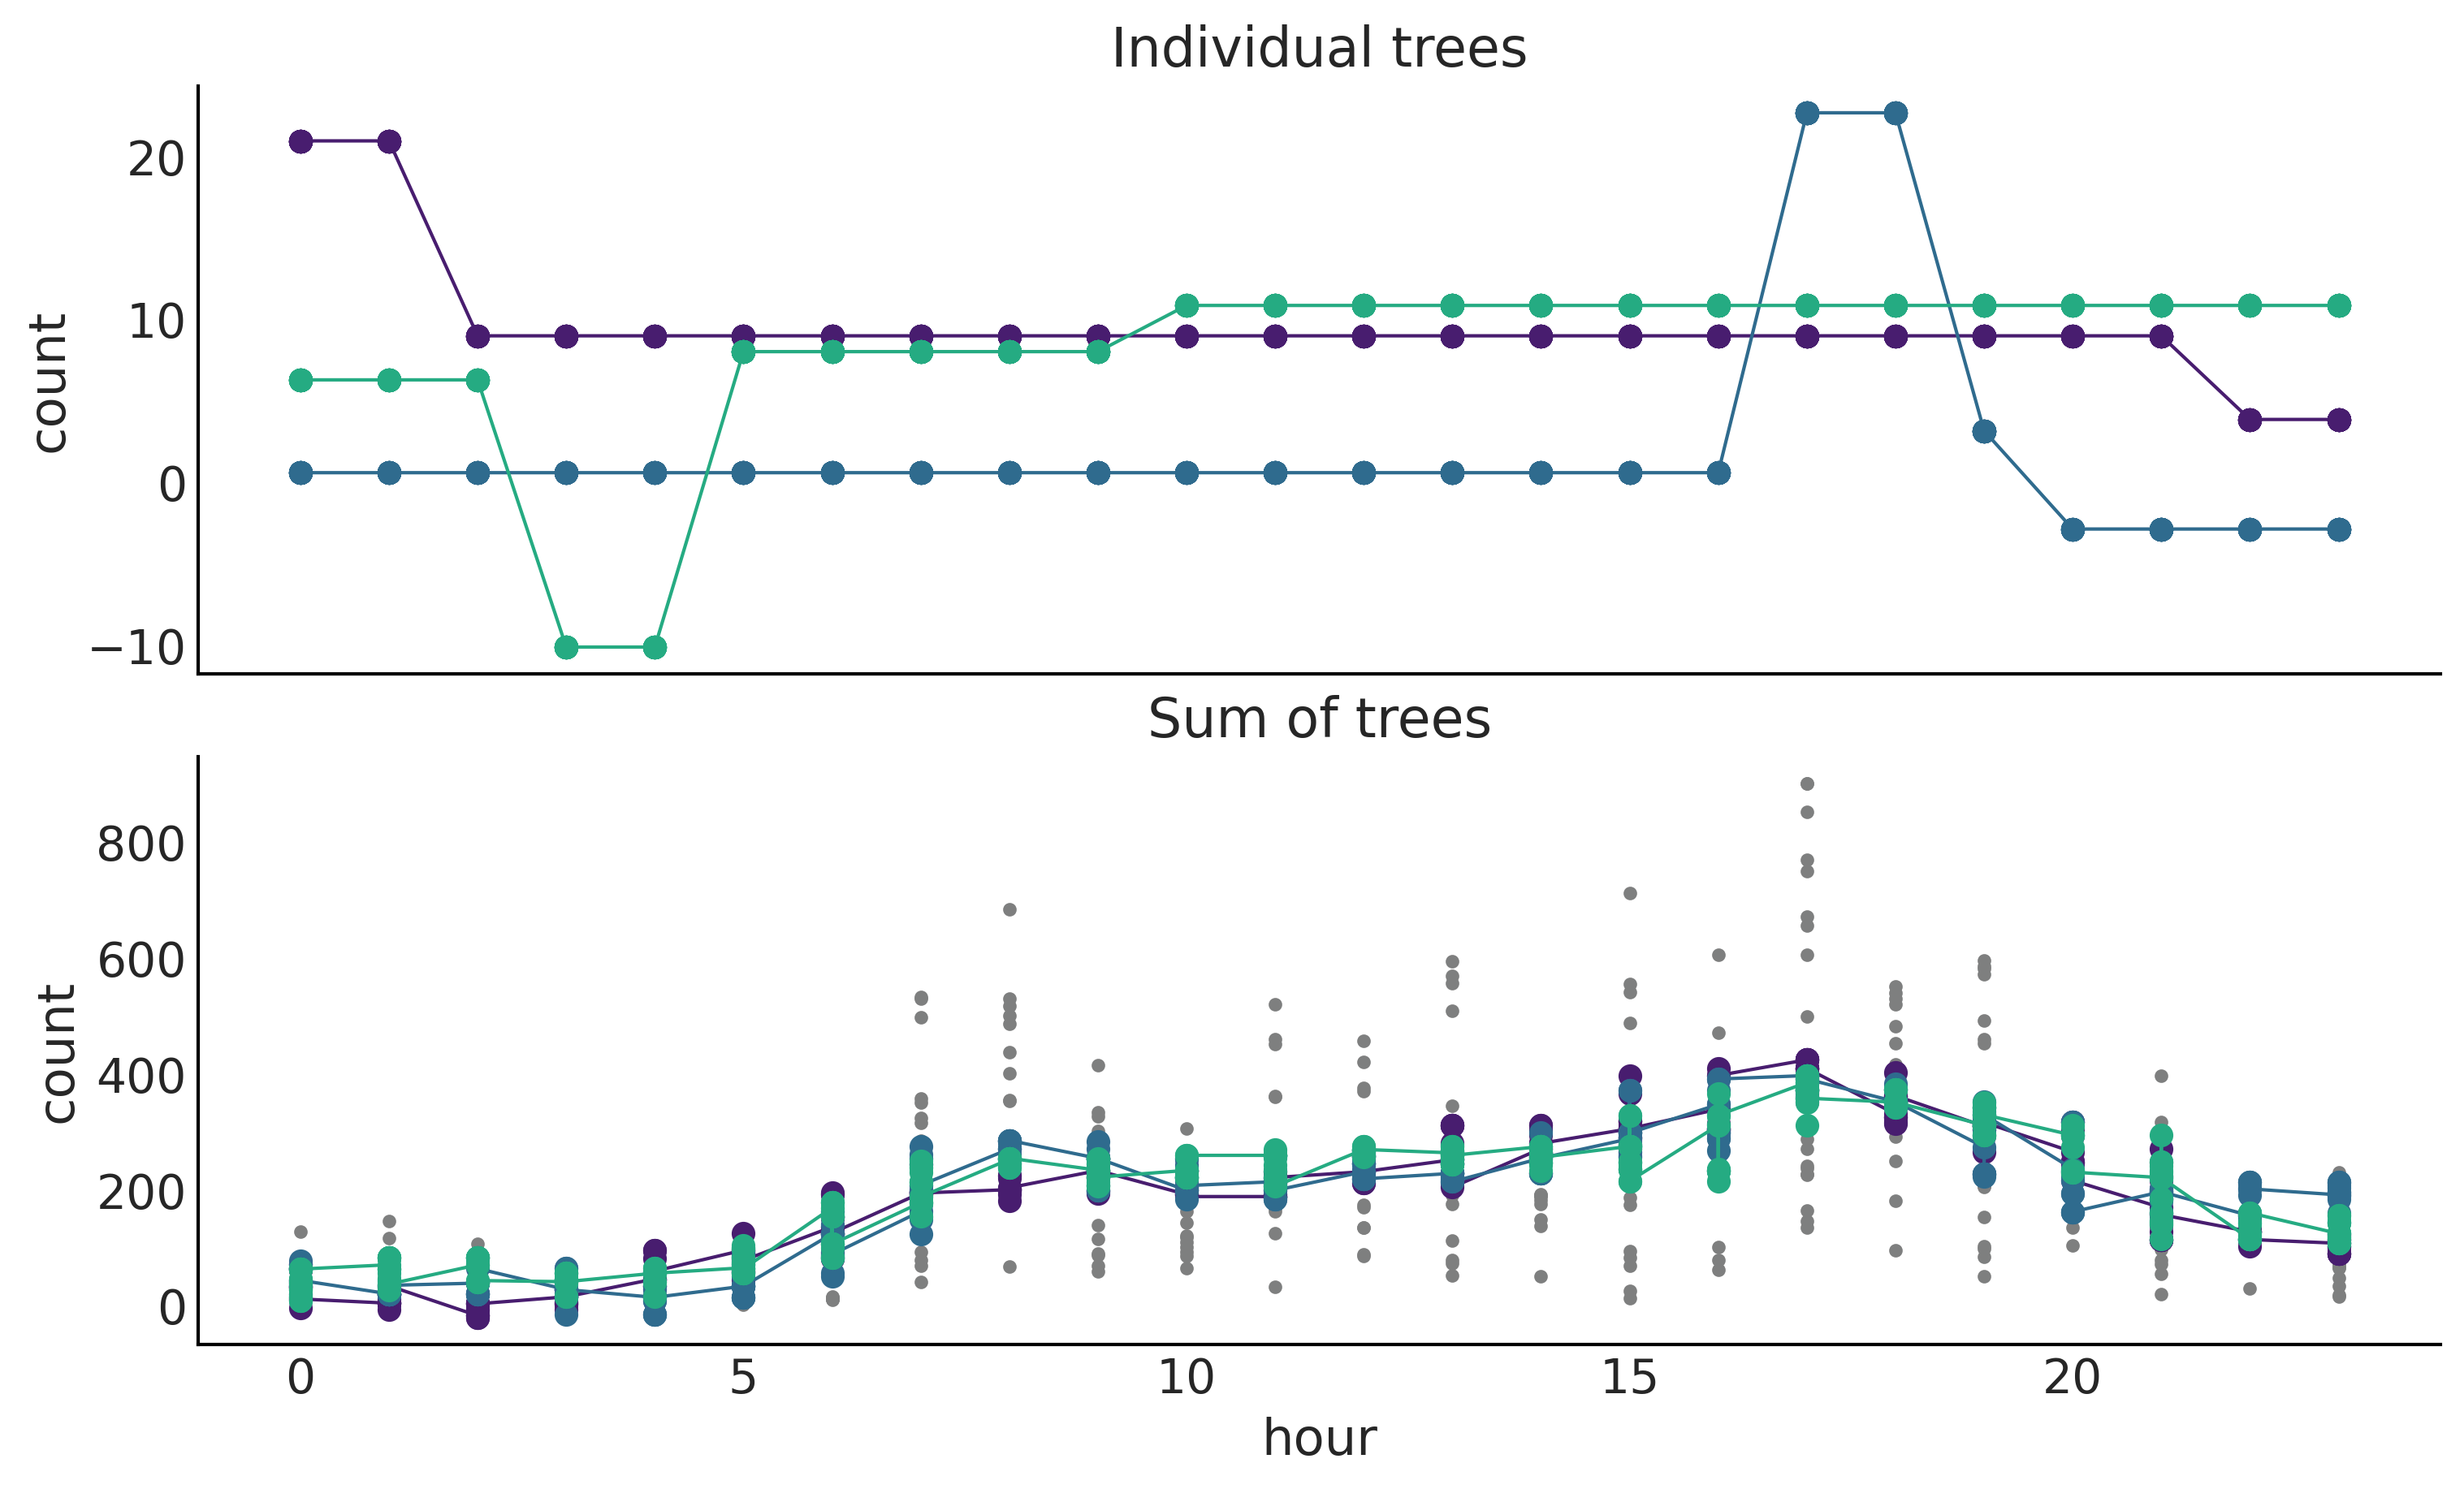

In [5]:
_, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].set_prop_cycle(cycler('color', viridish))
ax[1].set_prop_cycle(cycler('color', viridish))
for i in range(3):
    ax[0].plot(X, μ.owner.op.all_trees[i*10][0][i*2].predict(X)[0], "o-", lw=1)

posterior = idata_bart_g.posterior.stack(samples=("chain", "draw"))
for i in range(3):
    ax[1].plot(X, posterior["μ"].sel(draw=i*50), "o-", lw=1)
ax[1].plot(X, Y, "C2.", zorder=-1)

    
ax[0].set_ylabel("count")
ax[0].set_title("Individual trees")
ax[1].set_title("Sum of trees")
ax[1].set_xlabel("hour")
ax[1].set_ylabel("count")
plt.savefig('img/chp07/BART_bikes_samples.png')

/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/site-packages/arviz/plots/hdiplot.py:161: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/site-packages/arviz/plots/hdiplot.py:161: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


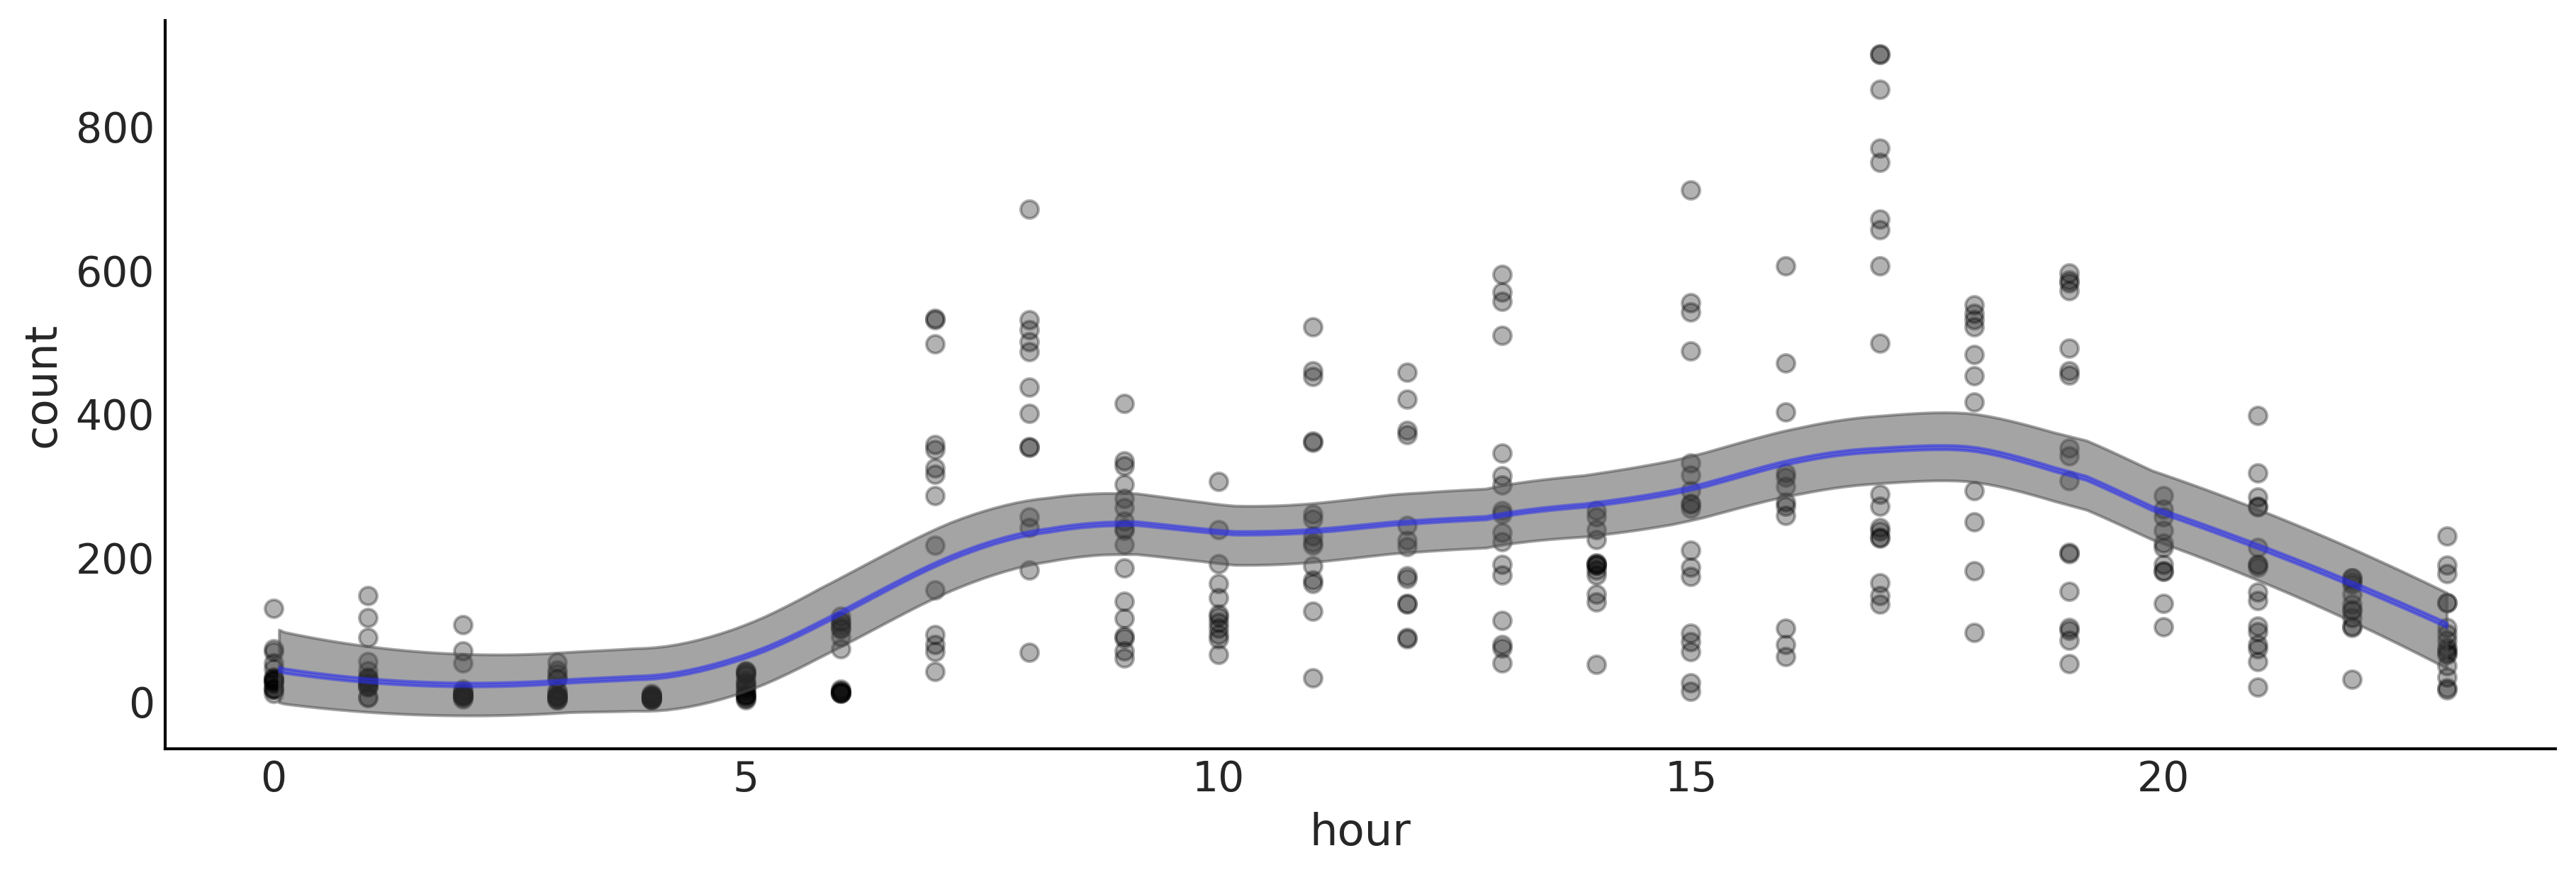

In [6]:
_, ax = plt.subplots(1, 1, figsize=(12, 4))

ax.plot(X, Y, "o", alpha=0.3, zorder=-1)
az.plot_hdi(X[:,0], posterior["μ"].T, smooth=True)
az.plot_hdi(X[:,0], posterior["μ"].T, hdi_prob=0.1, color="C4", smooth=True)

ax.set_xlabel("hour")
ax.set_ylabel("count")
plt.savefig('img/chp07/BART_bikes.png')

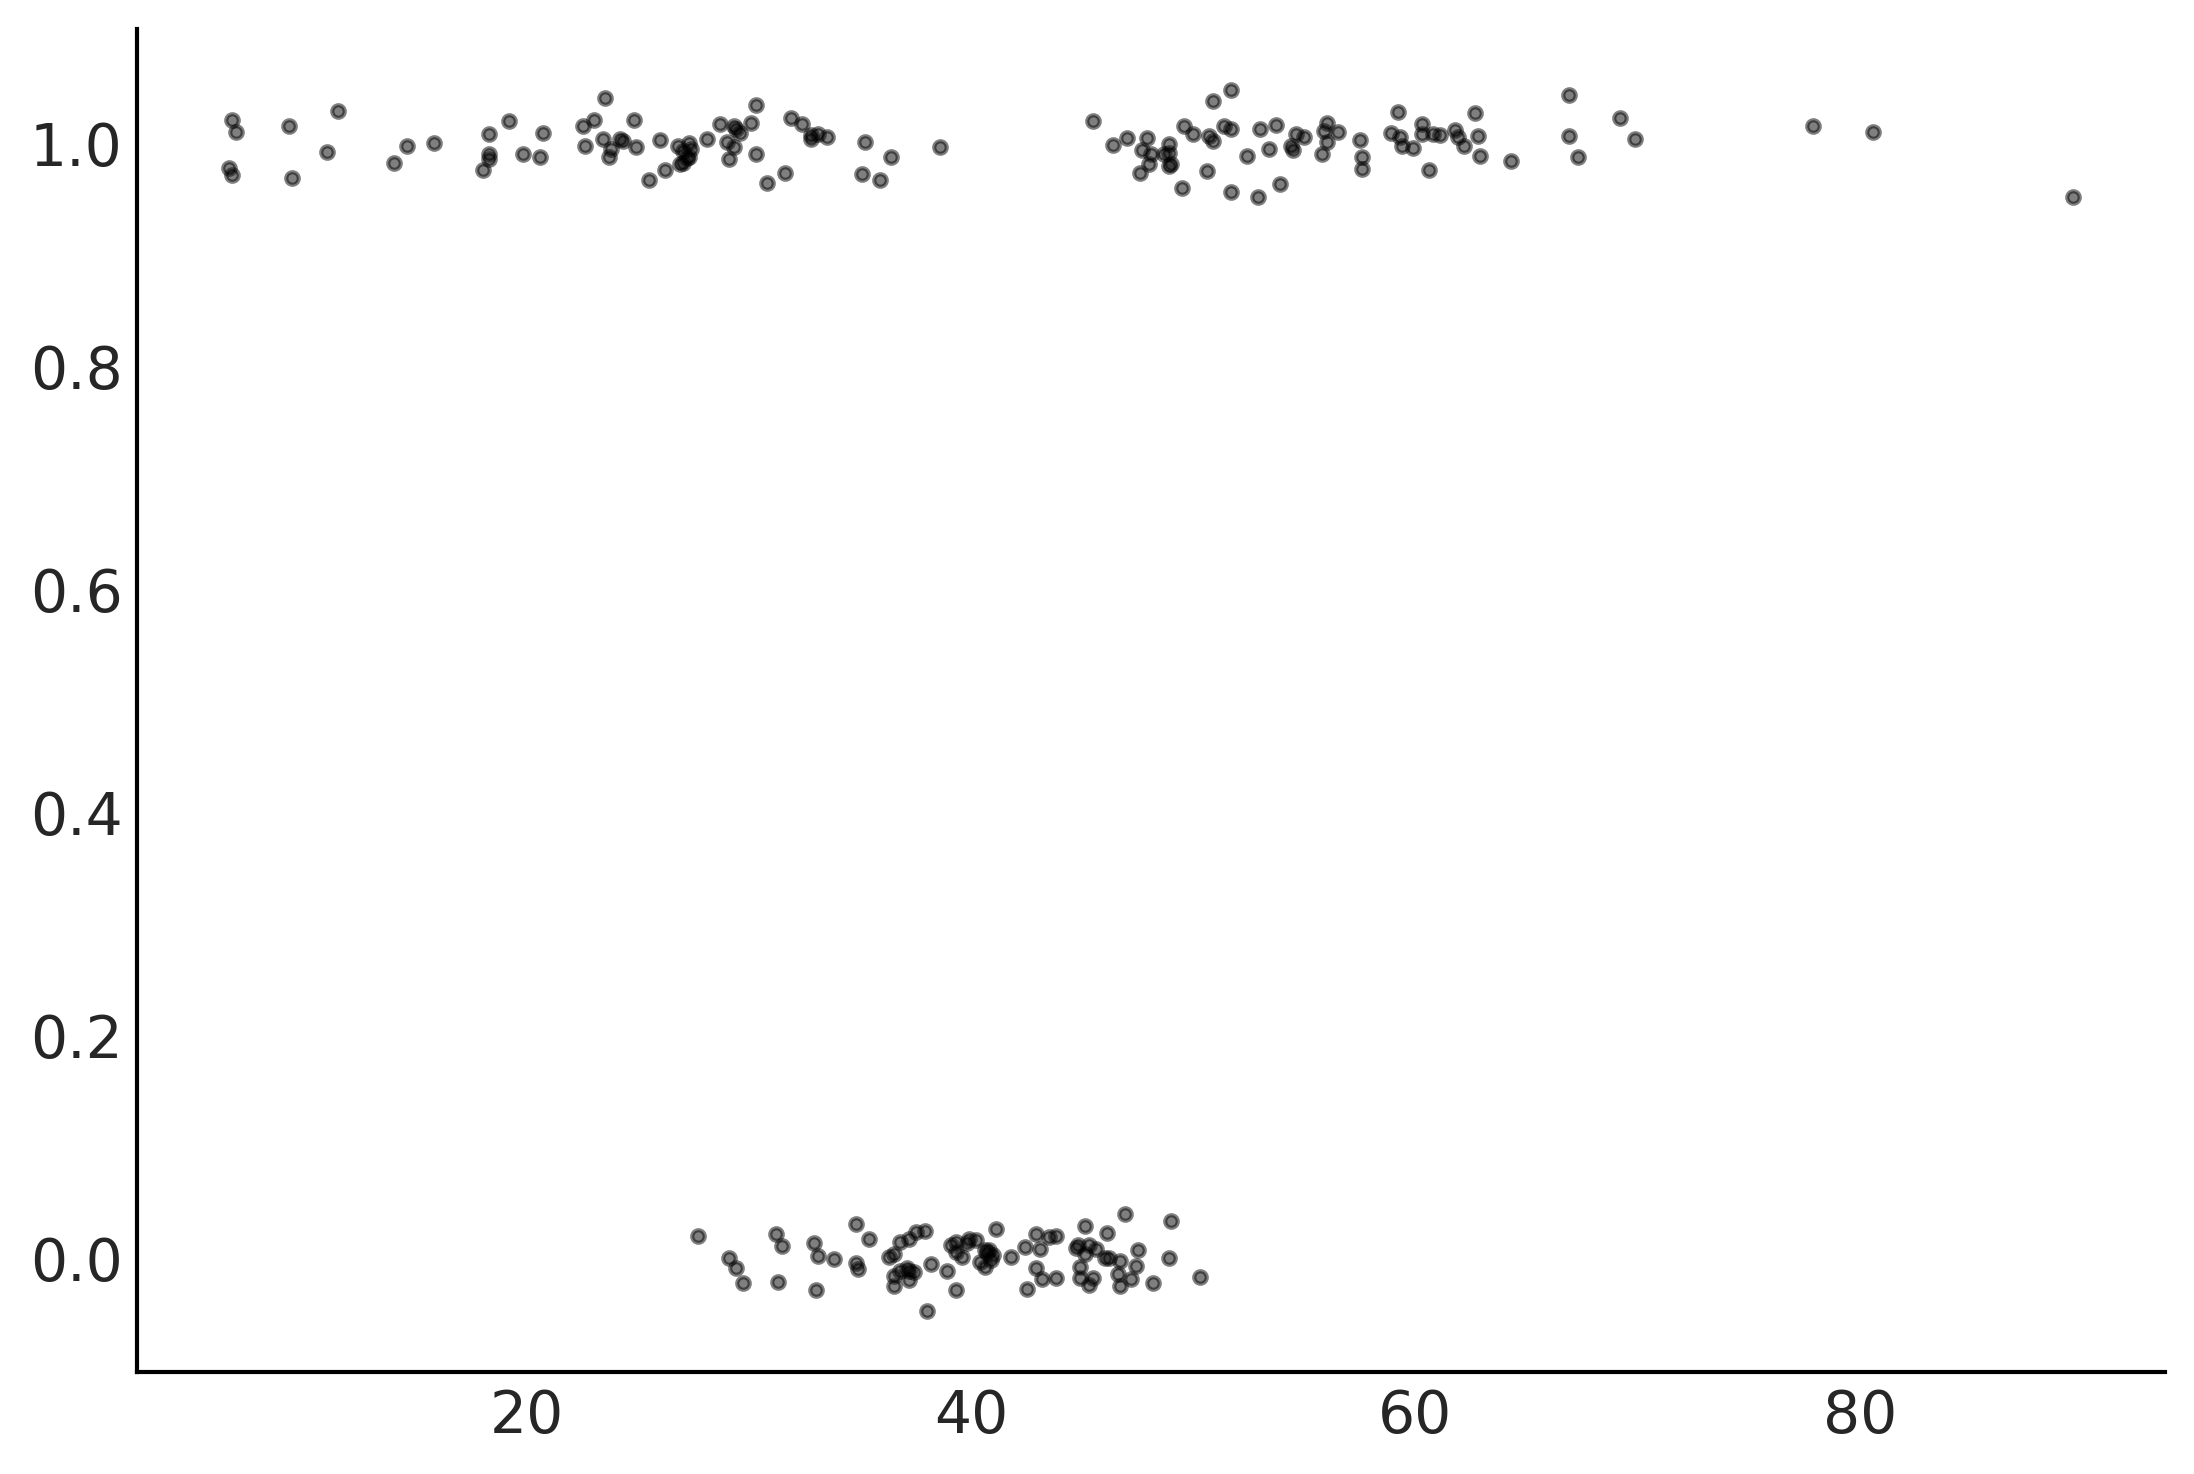

In [7]:
space_in = pd.read_csv("../data/space_influenza.csv")
X = np.atleast_2d(space_in["age"]).T
Y = space_in["sick"]


Y_jittered = np.random.normal(Y, 0.02)
plt.plot(X[:,0], Y_jittered, ".", alpha=0.5)

(generalized-bart-models)=

## 7.6. Generalized BART Models

The PyMC3 implementation of BART attempts to make it easy to use
different likelihoods [^6] similar to how the Generalized Linear Model
does as we saw in Chapter [3](chap2). Let us see how to use a
Bernoulli likelihood with BART. For this example we are going to use a
dataset of the Space Influenza disease, which affect mostly young and
old people, but not middle-age folks. Fortunately, Space Influenza is
not a serious concern as it is completely made up. In this dataset we
have a record of people that got tested for Space Influenza and whether
they are sick (1) or healthy (0) and also their age. Using the BART
model with Gaussian likelihood from Code Block
[bart_model_gauss](bart_model_gauss) as reference we see
that differences are small:

```{code-block} python
:name: bart_model_bern
:caption: bart_model_bern

with pm.Model() as model:
    μ = pm.BART("μ", X, Y, m=50,
                inv_link="logistic")
    y = pm.Bernoulli("y", p=μ, observed=Y)
    trace = pm.sample(2000, return_inferencedata=True)
```

[^6]: Other implementations are less flexible or require adjustments
    under the hood to make this work.

In [8]:
idatas = {}
ntrees = [2, 10, 20, 50]
for ntree in ntrees:
    with pm.Model() as bart_b:
        μ = pmb.BART('μ', X, Y, m=ntree,
                   )
        p = pm.Deterministic("p", pm.math.sigmoid(μ))
        y = pm.Bernoulli('y', p, observed=Y)
        idata_bart_b = pm.sample(2000, idata_kwargs={"log_likelihood": True})
        idatas[f"{ntree}"] = idata_bart_b

/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  self.pid = os.fork()
Multiprocess sampling (4 chains in 4 jobs)
PGBART: [μ]
/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using th

Output()

/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 8 seconds.
/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  self.pid = os.fork()
Multiprocess sampling (4 chains in 4 jobs)
PGBART: [μ]
/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterio

Output()

...

/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 18 seconds.
/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  self.pid = os.fork()
Multiprocess sampling (4 chains in 4 jobs)
PGBART: [μ]
/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysteri

Output()

/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 43 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [9]:
cmp = az.compare(idatas)
cmp

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
50,0,-56.705855,2.622001,0.000000,1.000000e+00,6.377242,0.000000,False,log
20,1,-62.068879,4.858239,5.363024,1.199396e-11,6.290423,0.383461,False,log
10,2,-71.675927,10.303130,14.970072,8.718359e-12,6.425286,0.705702,False,log
2,3,-112.749330,25.142012,56.043475,0.000000e+00,4.964574,2.596845,False,log


First we no longer need to define the $\sigma$ parameter as the
Bernoulli distribution has a single parameter `p`. For the definition of
BART itself we have one new argument, `inv_link`, this is the inverse
link function, which we need to restrict the values of $\mu$ to the
interval $[0, 1]$. For this purpose we instruct PyMC3 to use the
logistic function, as we did in Chapter [3](chap2) for logistic
regression).

{numref}`fig:BART_space_flu_comp` shows a comparison of the model in
Code Block [bart_model_bern](bart_model_bern) with 4
values for $m$, namely (2, 10, 20, 50) using LOO. And
{numref}`fig:BART_space_flu_fit` shows the data plus the fitted function
and HDI 94% bands. We can see that according to LOO $m=10$ and $m=20$
provides good fits. This is in qualitative agreement with a visual
inspection, as $m=2$ is a clear underfit (the value of the ELPD is low
but the difference between the in-sample and out-of-sample ELPD is not
that large) and $m=50$ seems to be overfitting (the value of the ELPD is
low and the difference between the in-sample and out-of-sample ELPD is
large).

```{figure} figures/BART_space_flu_comp.png
:name: fig:BART_space_flu_comp
:width: 8.00in
LOO comparison of the model in Code Block
[bart_model_bern](bart_model_bern) with $m$ values (2, 10,
20, 50). According to LOO, $m=10$ provides the best fit.
```

```{figure} figures/BART_space_flu_fit.png
:name: fig:BART_space_flu_fit
:width: 8.00in
BART fit to the Space Influenza dataset with 4 values for $m$ (2, 10,
20, 50). In line with LOO, the model with $m$ is underfitting and with
the one with $m=50$ is overfitting.
```

So far we have discussed regressions with a single covariate, we do this
for simplicity. However it is possible to fit datasets with more
covariates. This is trivial from the implementation perspective in
PyMC3, we just need to pass an $X$ 2-d array containing more than 1
covariate. But it raises some interesting statistical questions, like
how to easily interpret a BART model with many covariates or how to find
out how much each covariate is contributing to the outcome. In the next
sections we will show how this is done.

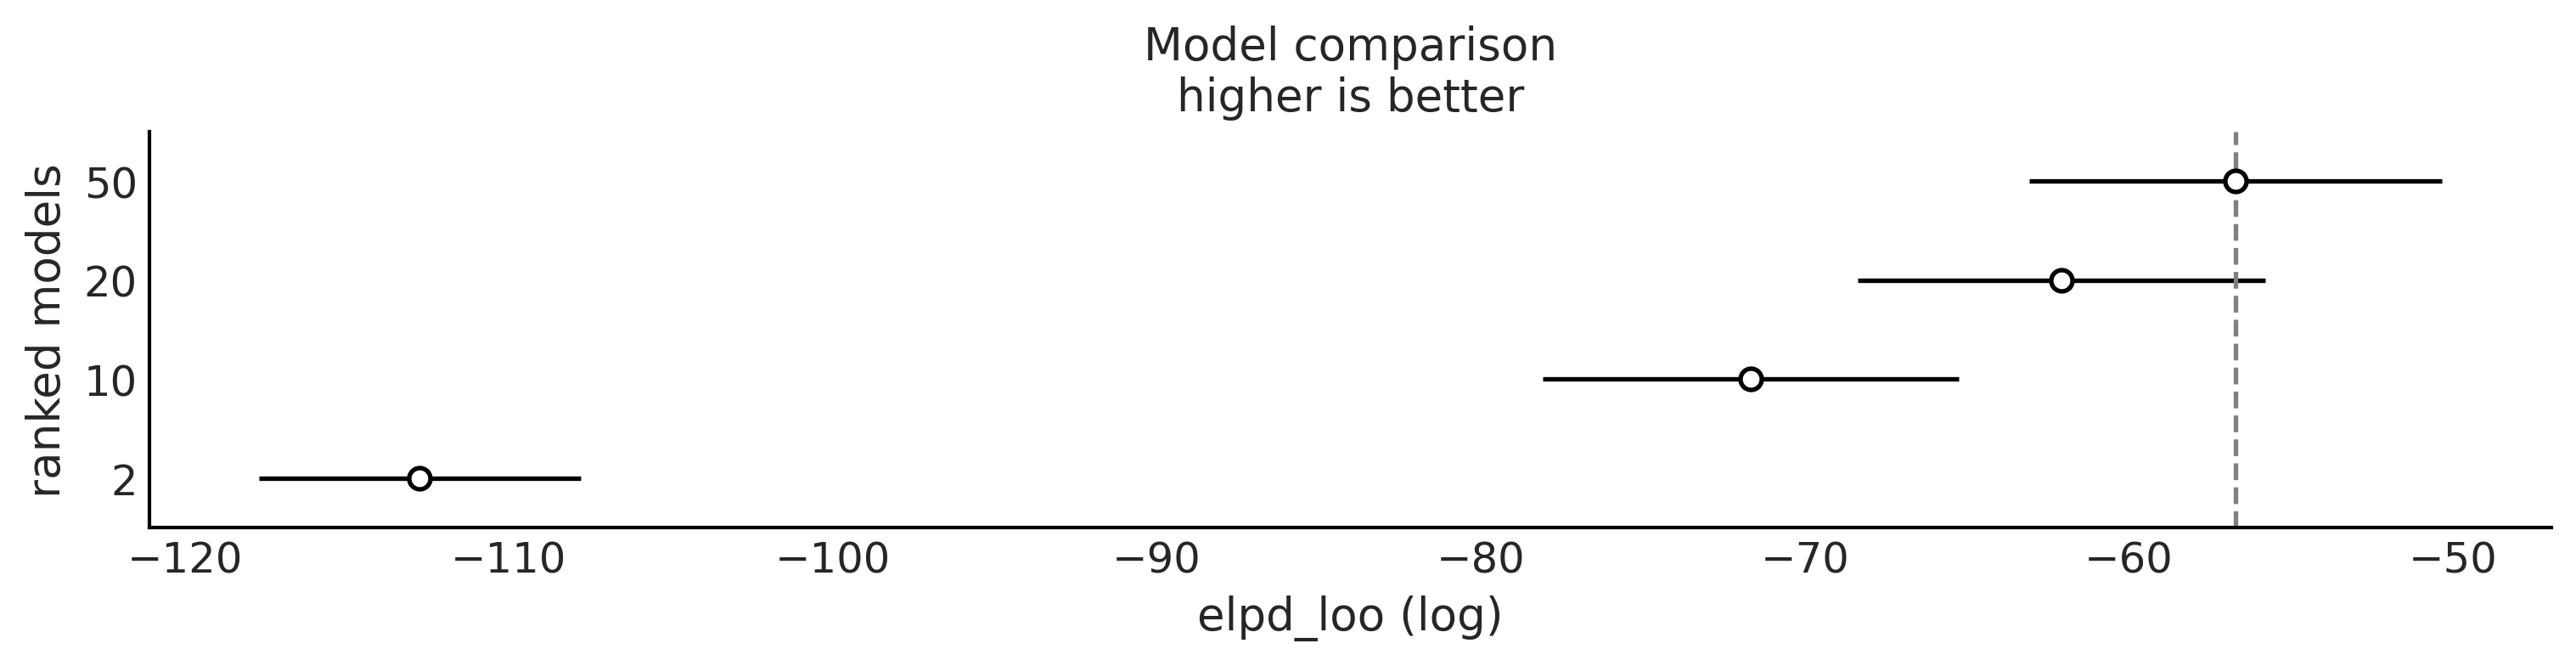

In [10]:
az.plot_compare(cmp, figsize=(10, 2.5))
plt.savefig("img/chp07/BART_space_flu_comp.png")

/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/site-packages/arviz/plots/hdiplot.py:161: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/site-packages/arviz/plots/hdiplot.py:161: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/site-packages/arviz/plots/hdiplot.py:161: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circ

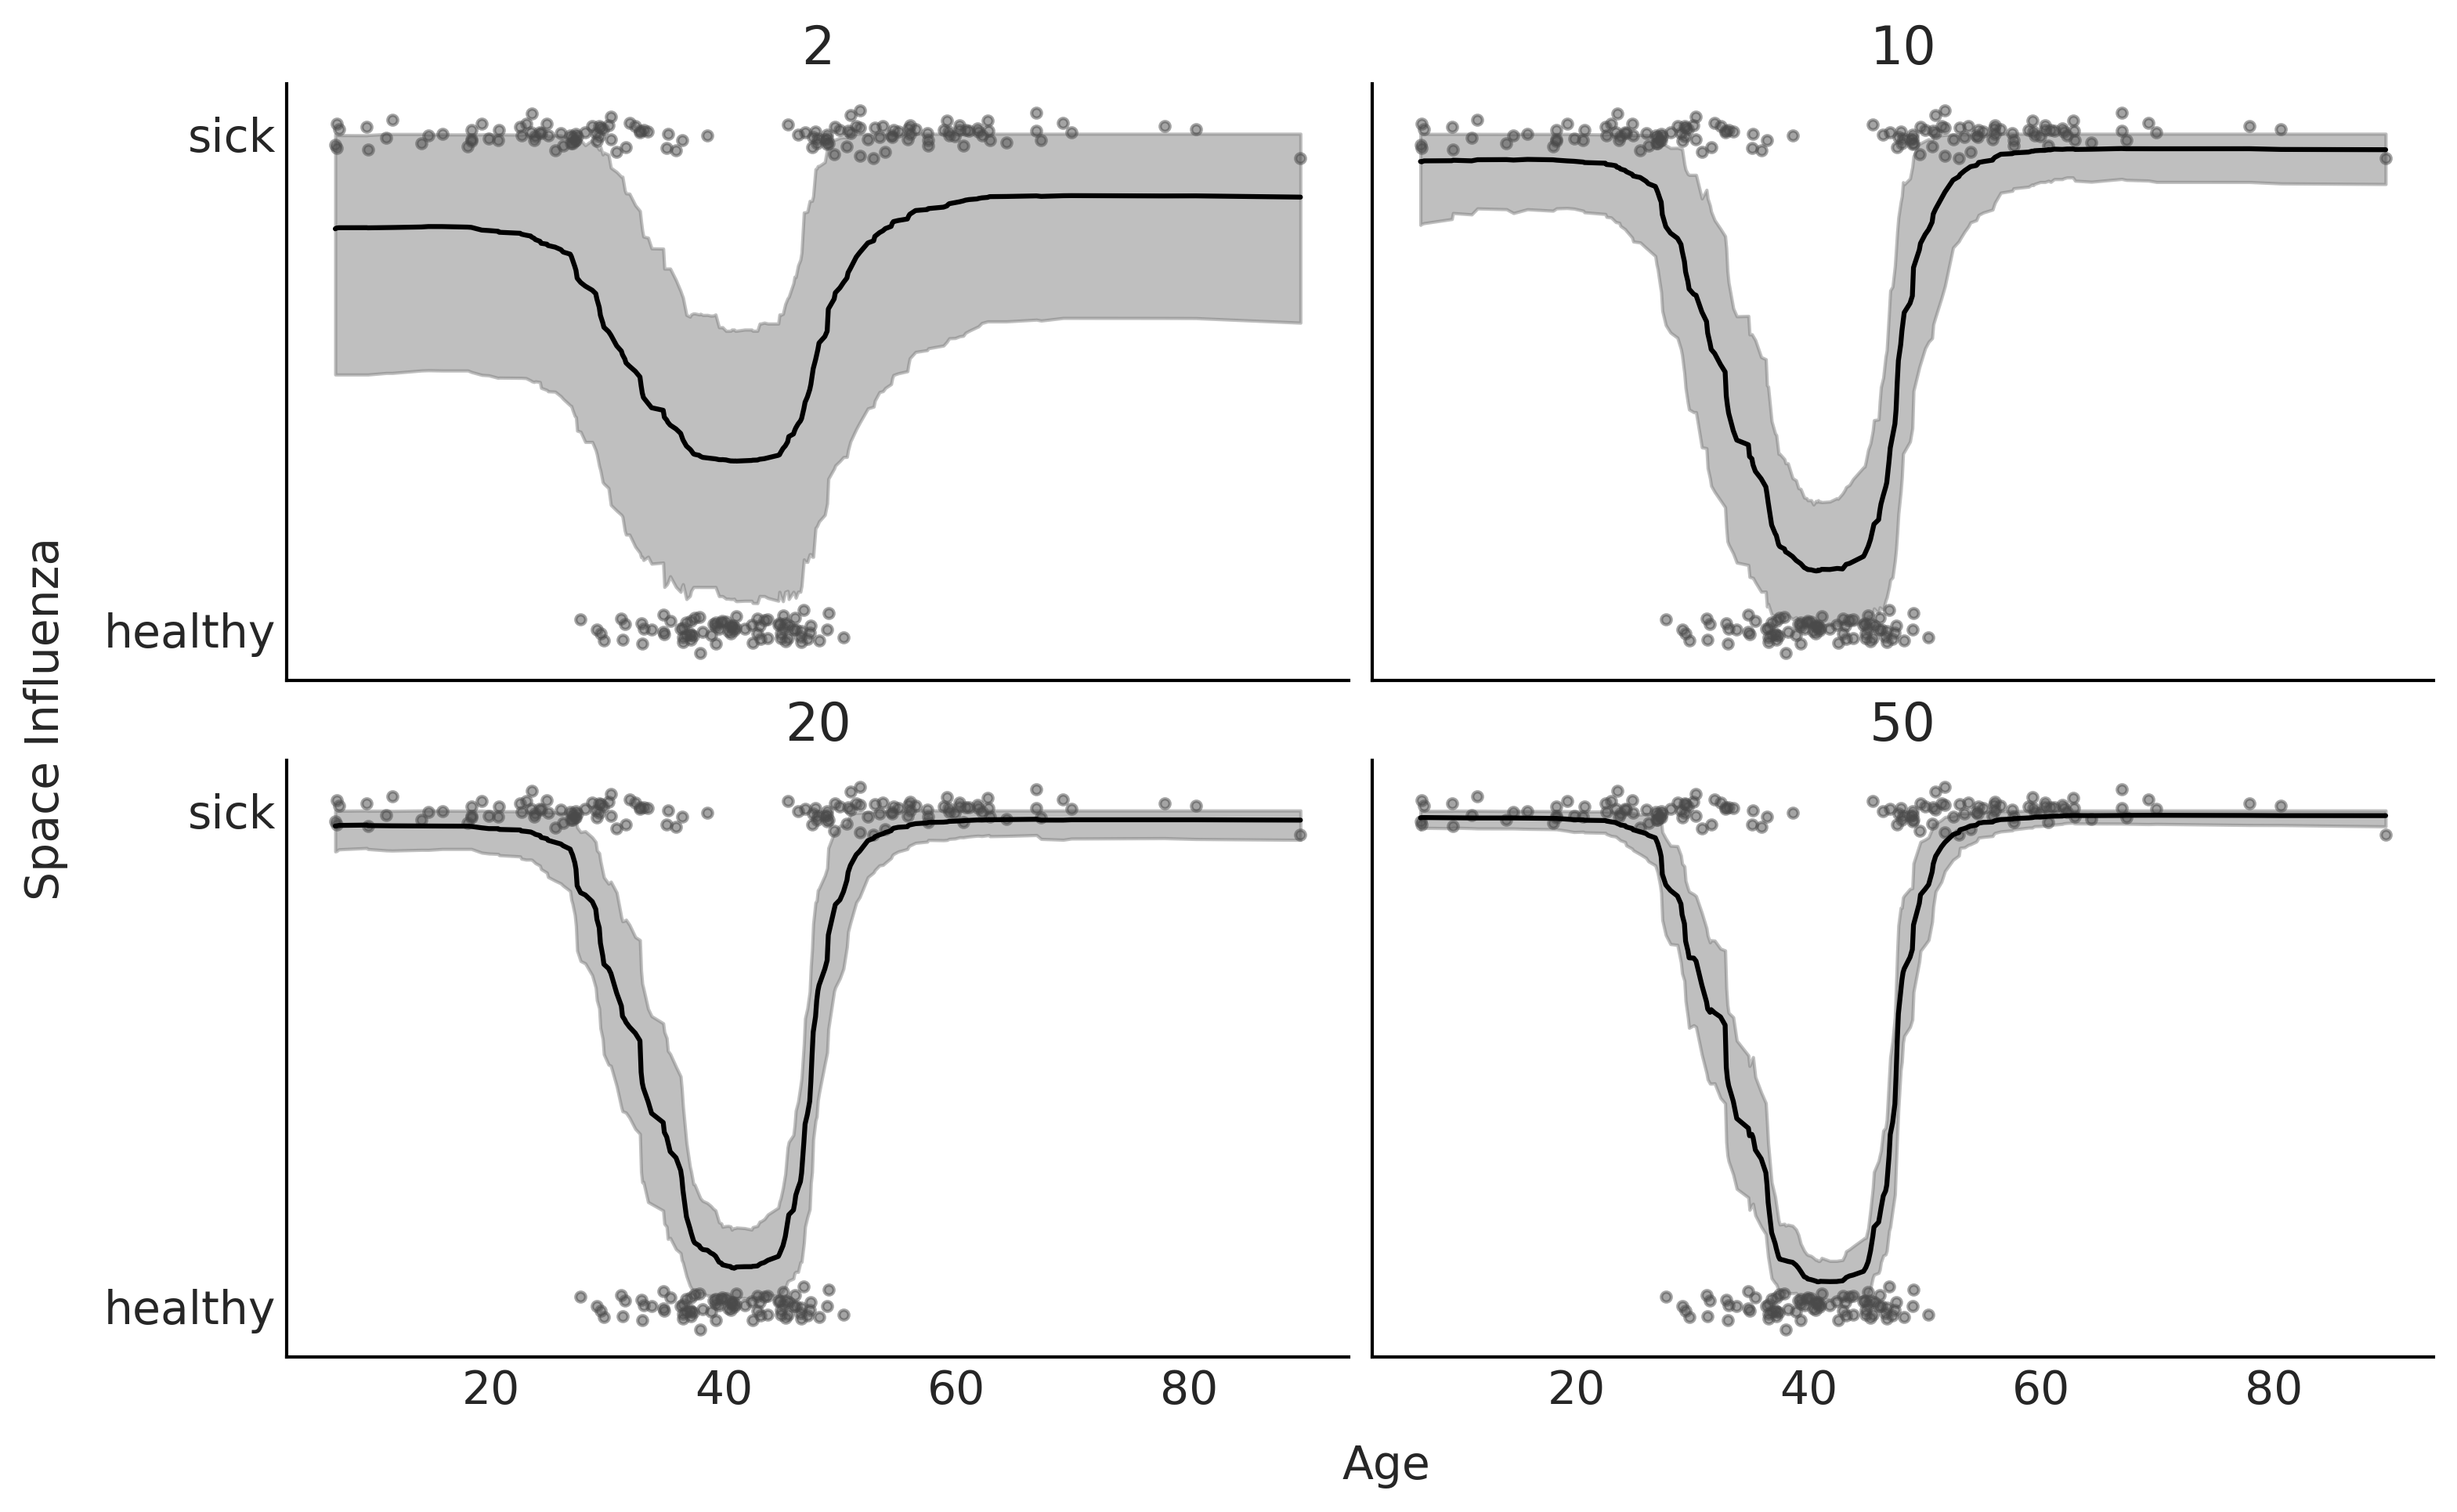

In [11]:
fig, axes = plt.subplots(2,2, figsize=(10, 6), sharey=True, sharex=True)

for ax, (mtree, idata) in zip(np.ravel(axes), idatas.items()):
    μs = idata.posterior["p"].stack({"draws":["chain",  "draw"]})

    ax.plot(X, Y_jittered, "C1.", alpha=0.5)

    X_idx = np.argsort(X[:,0])
    ax.plot(X[:,0][X_idx], np.mean(μs, 1)[X_idx], 'k-') 
    
    az.plot_hdi(X[:,0], μs.T, ax=ax, smooth=False, color="0.5") # una banda con el 94% Highest Density Interval
    ax.set_title(mtree)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["healthy", "sick"])
fig.text(0.55, -0.04, 'Age', ha='center', size=14)
fig.text(-0.03, 0.5, 'Space Influenza', va='center', size=14, rotation=90)
plt.savefig("img/chp07/BART_space_flu_fit.png", bbox_inches="tight")

(interpretability-of-barts)=

## 7.7. Interpretability of BARTs

Individual decision trees are generally easy to interpret, but this is
no longer true when we add a bunch of trees together. One may think that
the reason is that by adding trees we get some weird unrecognizable or
difficult to characterize object, but actually the sum of trees is just
another tree. The difficulty to interpret this *assembled* tree is that
for a complex problem the decision rules will be hard to grasp. This is
like playing a song on piano, playing individual notes is fairly easy,
but playing a combination of notes in a musical-pleasant way is both
what makes for the richness of sound and complexity in individual
interpretation.

We may still get some useful information by directly inspecting a sum of
trees (see Section {ref}`sec:variable_selection`, but not as
transparent or useful as with a simpler individual tree. Thus to help us
interpret results from BART models we generally rely on model
diagnostics tools {cite:p}`Molnarbook, Molnar2020`, e.g. tools also used for
multivariate linear regression and other non-parametric methods. We will
discuss two related tools below: **Partial Dependence Plots** (PDP)
{cite:p}`Friedman2001` and **Individual Conditional Expectation** (ICE) plots
{cite:p}`Goldstein2014`.

(partial-dependence-plots)=

### 7.7.1. Partial Dependence Plots

A very common method that appears in the BART literature is the so
called Partial Dependence Plot (PDP) {cite:p}`Friedman2001` (see
{numref}`fig:pdp_fake_example`). A PDP shows how the value of the
predicted variable changes when we change a covariate while averaging
over the marginal distribution of the rest of the covariates. That is,
we compute and then plot:

```{math} 
:label: eq:partial_dependence
\tilde{Y}_{\boldsymbol{X}_i}= \mathbb{E}_{\boldsymbol{X}_{-i}}[\tilde{Y}(\boldsymbol{X}_i, \boldsymbol{X}_{-i})] \approx \frac{1}{n}\sum_{j=1}^{n} \tilde{Y}(\boldsymbol{X}_i, \boldsymbol{X}_{-ij})

```

where $\tilde{Y}_{\boldsymbol{X}_i}$ is the value of the predicted
variable as a function of $\boldsymbol{X}_i$ while all the variables
except $i$ ($\boldsymbol{X}_{-i}$) have been marginalized. In general
$X_i$ will be a subset of 1 or 2 variables, the reason being that
plotting in higher dimensions is generally difficult.

As shown in Equation {eq}`eq:partial_dependence` the expectation can be
approximated numerically by averaging over the predicted values
conditioned on the observed $\boldsymbol{X}_{-i}$. Notice however, this
implies that some of the combinations in
$\boldsymbol{X}_i, \boldsymbol{X}_{-ij}$ might not correspond to actual
observed combinations. Moreover it might even be the case that some of
the combinations are not possible to observe. This is similar to what we
already discussed regarding counterfactuals plots introduced in Chapter
[3](chap2). In fact partial dependence plots are one kind of
counterfactual device.

```{figure} figures/partial_dependence_plot.png
:name: fig:pdp_fake_example
:width: 8.00in
Partial dependence plot. Partial contribution to $Y$ from each variable
$X_i$ while marginalizing the contributions from the rest of the
variables ($X_{-i}$). The gray bands represent the HDI 94%. Both the
mean and HDI bands has been smoothed (see `plot_ppd` function). The
rugplot, the black bars at the bottom of each subplot, shows the
observed values for each covariate.
```

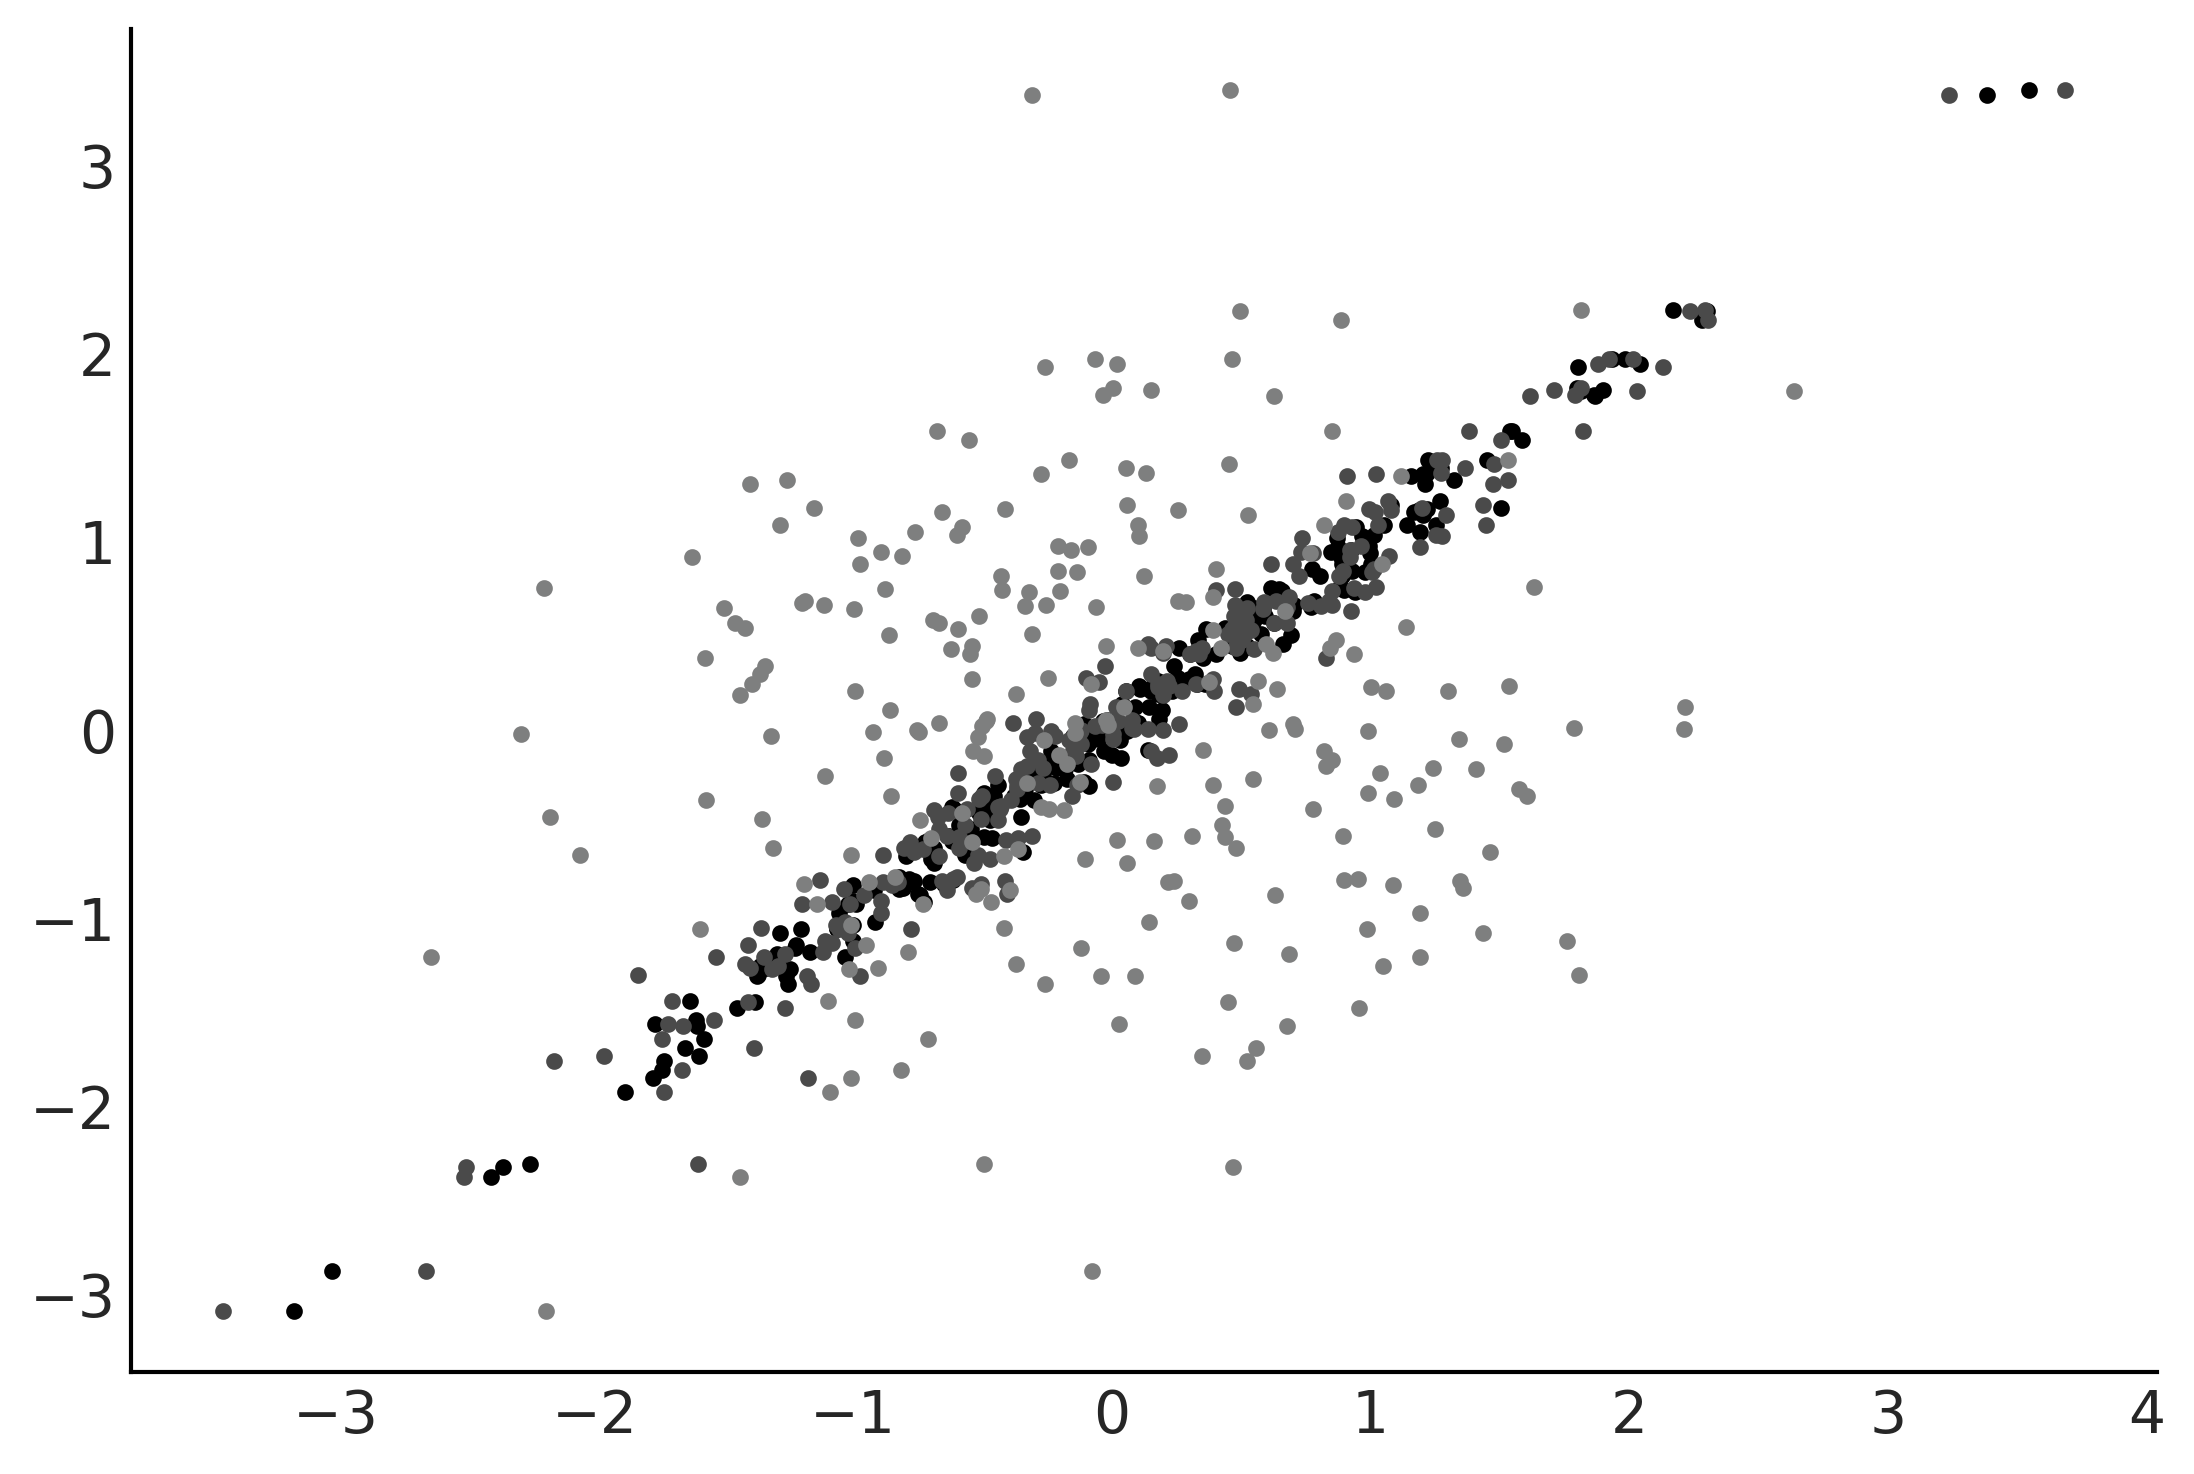

In [12]:
X = np.random.normal(0, 1, size=(3, 250)).T
Y = np.random.normal(0, 1, size=250)
X[:,0] = np.random.normal(Y, 0.1)
X[:,1] = np.random.normal(Y, 0.2)

plt.plot(X, Y, '.');

In [13]:
with pm.Model() as model:
    μ = pmb.BART('μ', X, Y, m=50)
    σ = pm.HalfNormal('σ', 1)
    y = pm.Normal('y', μ, σ, observed=Y)
    trace_u = pm.sample(2000, tune=1000, random_seed=42)

/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  self.pid = os.fork()
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>PGBART: [μ]
>NUTS: [σ]
/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is

Output()

/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 55 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


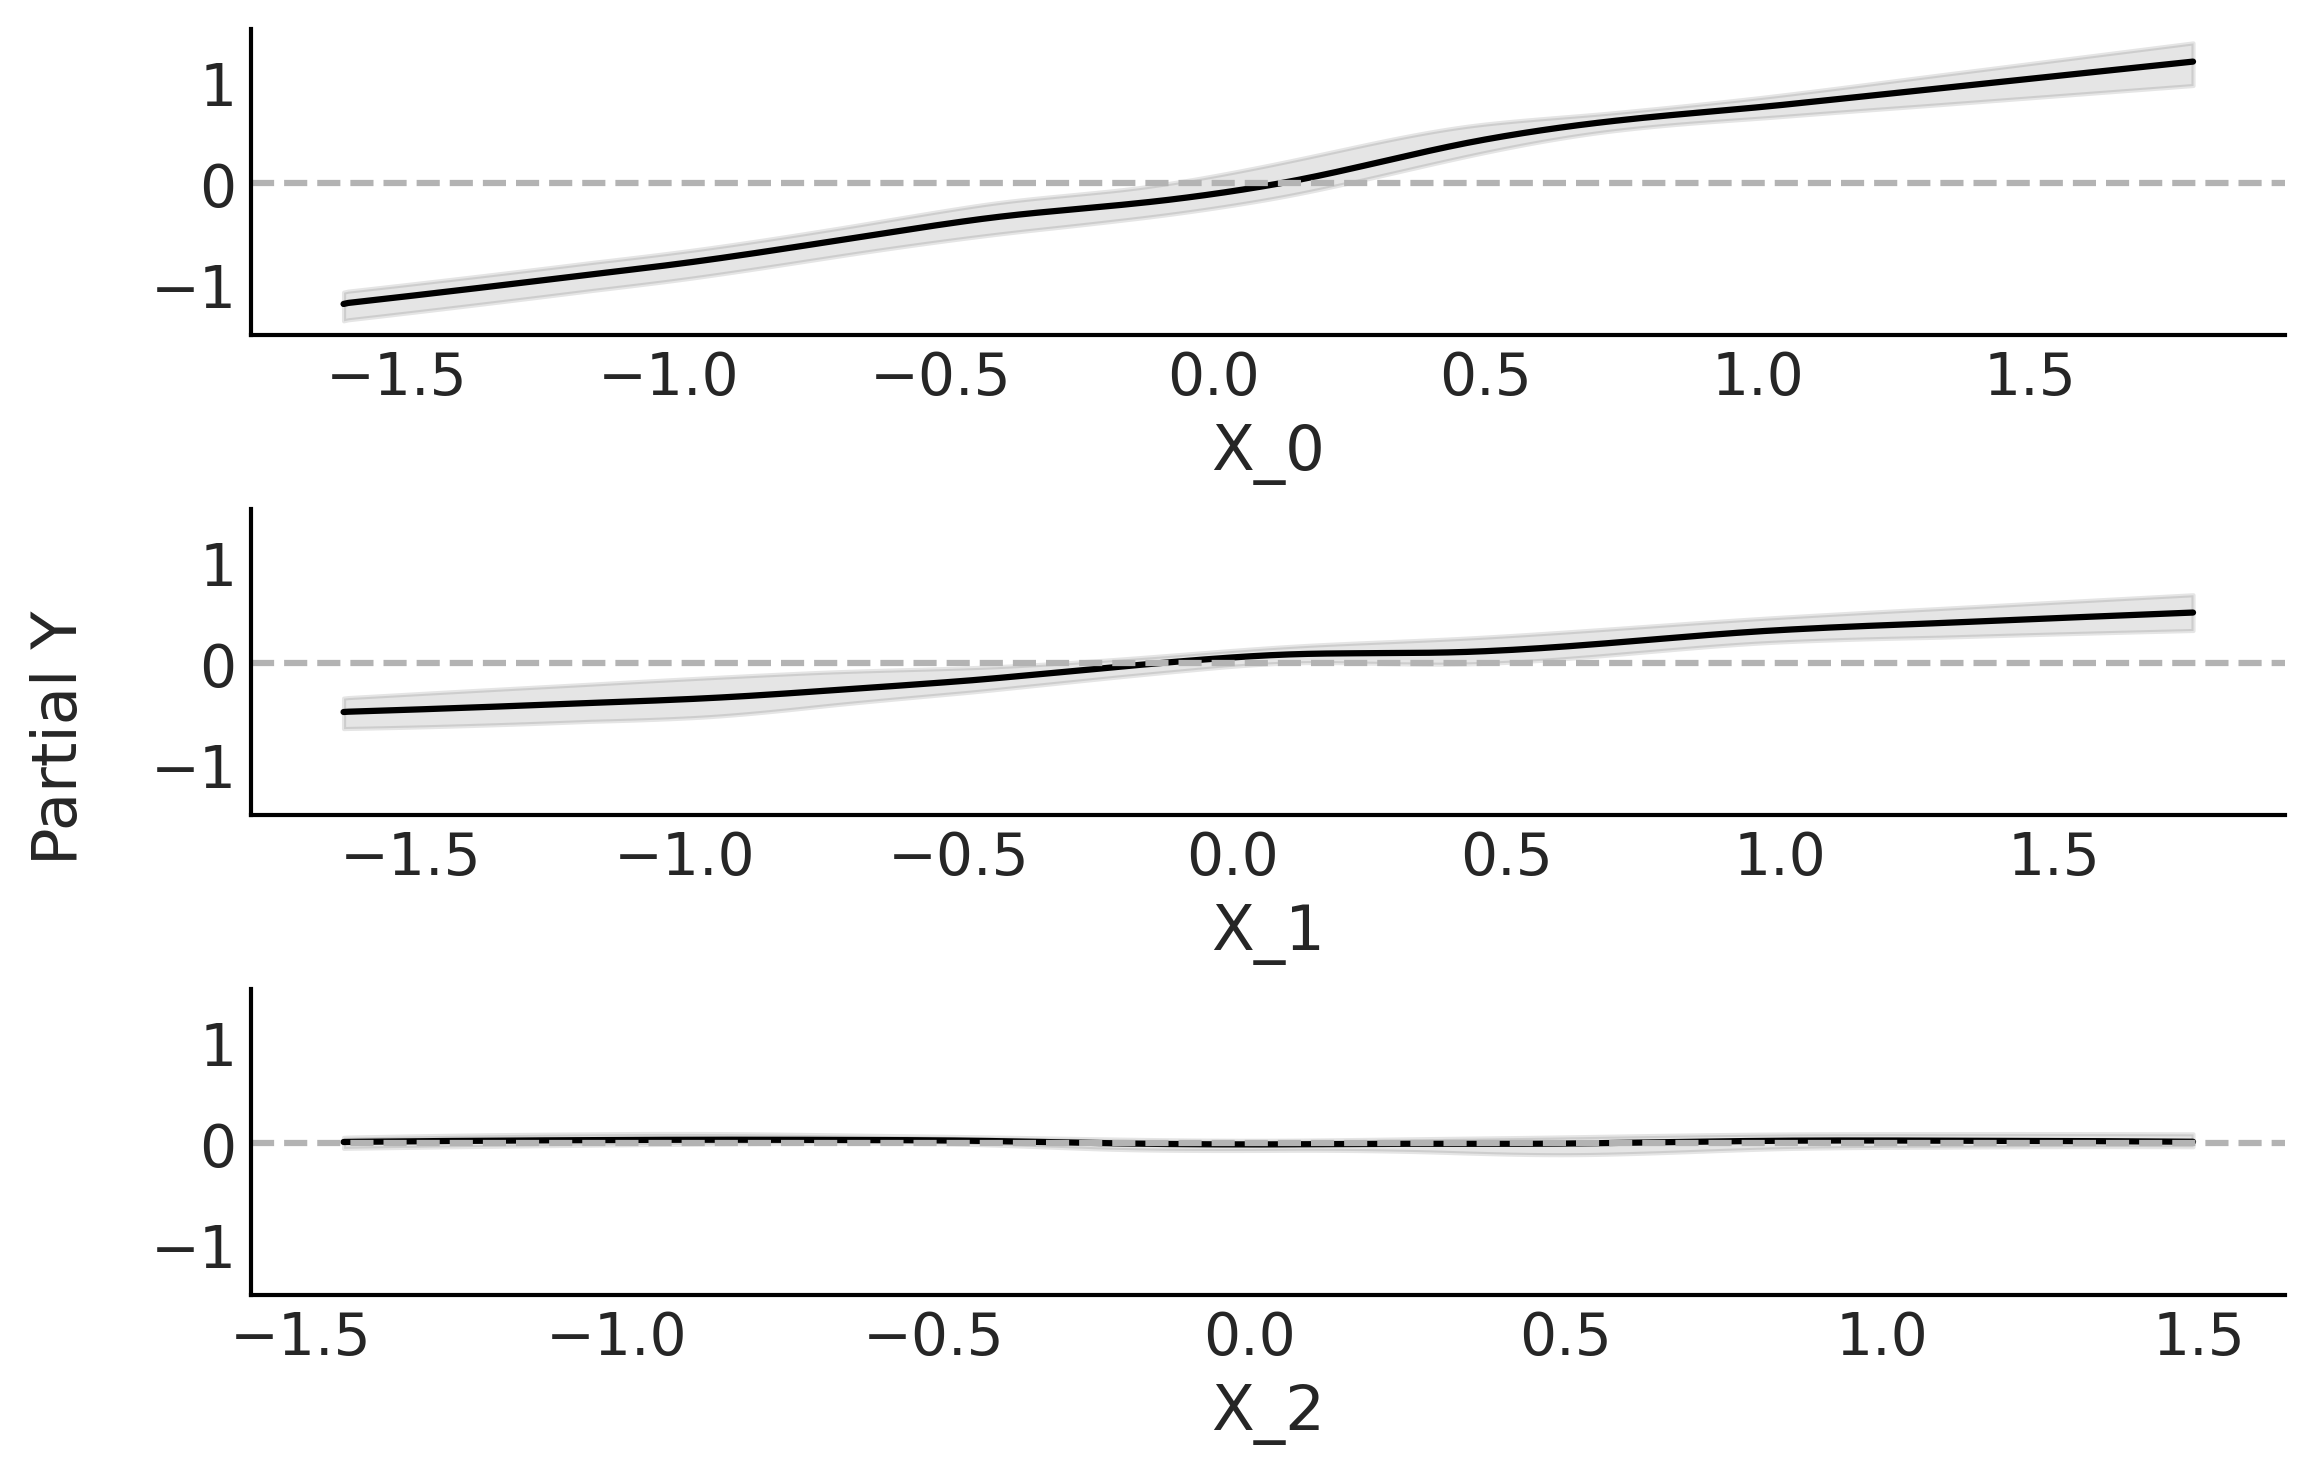

In [14]:
pmb.plot_pdp(μ, X, grid="long")
plt.savefig("img/chp07/partial_dependence_plot.png", bbox_inches="tight")

{numref}`fig:pdp_fake_example` shows a PDP after fitting a BART model to
synthetic data: $Y \sim \mathcal{N}(0, 1)$
$X_{0} \sim \mathcal{N}(Y, 0.1)$ and $X_{1} \sim \mathcal{N}(Y, 0.2)$
$X_{2} \sim \mathcal{N}(0, 1)$. We can see that both $X_{0}$ and $X_{1}$
show a linear relation with $Y$, as expected from the generation process
of the synthetic data. We can also see that the effect of $X_{0}$ on $Y$
is stronger compared to $X_{1}$, as the slope is steeper for $X_{0}$.
Because the data is sparser at the tails of the covariate (they are
Gaussian distributed), these regions show higher uncertainty, which is
desired. Finally, the contribution from $X_{2}$ is virtually negligible
along the entire range of the variable $X_{2}$.

Let now go back to the bikes dataset. This time we will model the number
of rented bikes (the predicted variable) with four covariates; the hour
of the day, the temperature, the humidity and the wind speed.
{numref}`fig:partial_dependence_plot_bikes` shows the partial dependence
plot after fitting the model. We can see that the partial dependence
plot for the hour of the day looks pretty similar to
{numref}`fig:bart_bikes`, the one we obtained by fitting this variable
in the absence of others. As the temperature increases the number of
rented bikes increase too, but at some point this trend levels off.
Using our external domain knowledge we could conjecture this pattern is
reasonable as people are not too motivated to bike when the temperature
is too low, but riding a bike at temperatures that are *too high* is
also a little bit less appealing. The humidity shows a flat trend
followed by a negative contribution, again we can imagine why a higher
humidity reduces people's motivation to ride a bike. The wind speed
shows an even flatter contribution, but still we see an effect, as it
seems that less people are prone to rent a bike under windier
conditions.

```{figure} figures/partial_dependence_plot_bikes.png
:name: fig:partial_dependence_plot_bikes
:width: 8.00in
Partial dependence plot. Partial contribution to the number of rented
bikes from the variables, hour, temperature, humidity and windspeed
while marginalizing the contributions from the rest of the variables
($X_{-i}$). The gray bands represent the HDI 94%. Both the mean and HDI
bands have been smoothed (see `plot_ppd` function). The rugplot, the
black bars at the bottom of each subplot, shows the observed values for
each covariate.
```

One assumption when computing partial dependence plots is that variables
$X_i$ and $X_{-i}$ are uncorrelated, and thus we perform the average
across the marginals. In most real problem this is hardly the case, and
then partial dependence plot can hide relationships in the data.
Nevertheless if the dependence between the subset of chosen variables is
not too strong then partial dependence plots can be useful summaries
{cite:p}`Friedman2001`.

::: {admonition} Computational cost of partial dependence

Computing partial dependence plots is computationally demanding.
Because at each point that we want to evaluate the variable $X_i$
we need to compute $n$ predictions (with $n$ being the sample size).
And for BART to obtain a prediction
$\tilde Y$ we need to first sum over $m$ trees to get a point-estimate
of $Y$ and then we also average over the entire posterior distribution
of sum of trees to get credible interval. This ends up requiring quite a
bit of computation! If needed, one way to reduce computations is to
evaluate $X_i$ at $p$ points with $p << n$. We could choose $p$ equally
spaced points or maybe at some quantiles. Alternative we can achieve a
dramatic speed-up if instead of marginalize over $\boldsymbol{X}_{-ij}$
we fix them at their mean value. Of course this means we will be losing
information and it may happen that the mean value is not actually very
representative of the underlying distribution. Another option, specially
useful for large datasets, is to subsample $\boldsymbol{X}_{-ij}$.
:::

In [15]:
X = data[["hour", "temperature", "humidity", "windspeed"]]
Y = data["count"]

In [16]:
with pm.Model() as bart_model_g:
    σ = pm.HalfNormal('σ', Y.std())
    μ = pmb.BART('μ', X, Y, m=50)
    y = pm.Normal('y', μ, σ, observed=Y)
    trace_bart = pm.sample(2000)

/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  self.pid = os.fork()
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [σ]
>PGBART: [μ]
/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is

Output()

/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 42 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


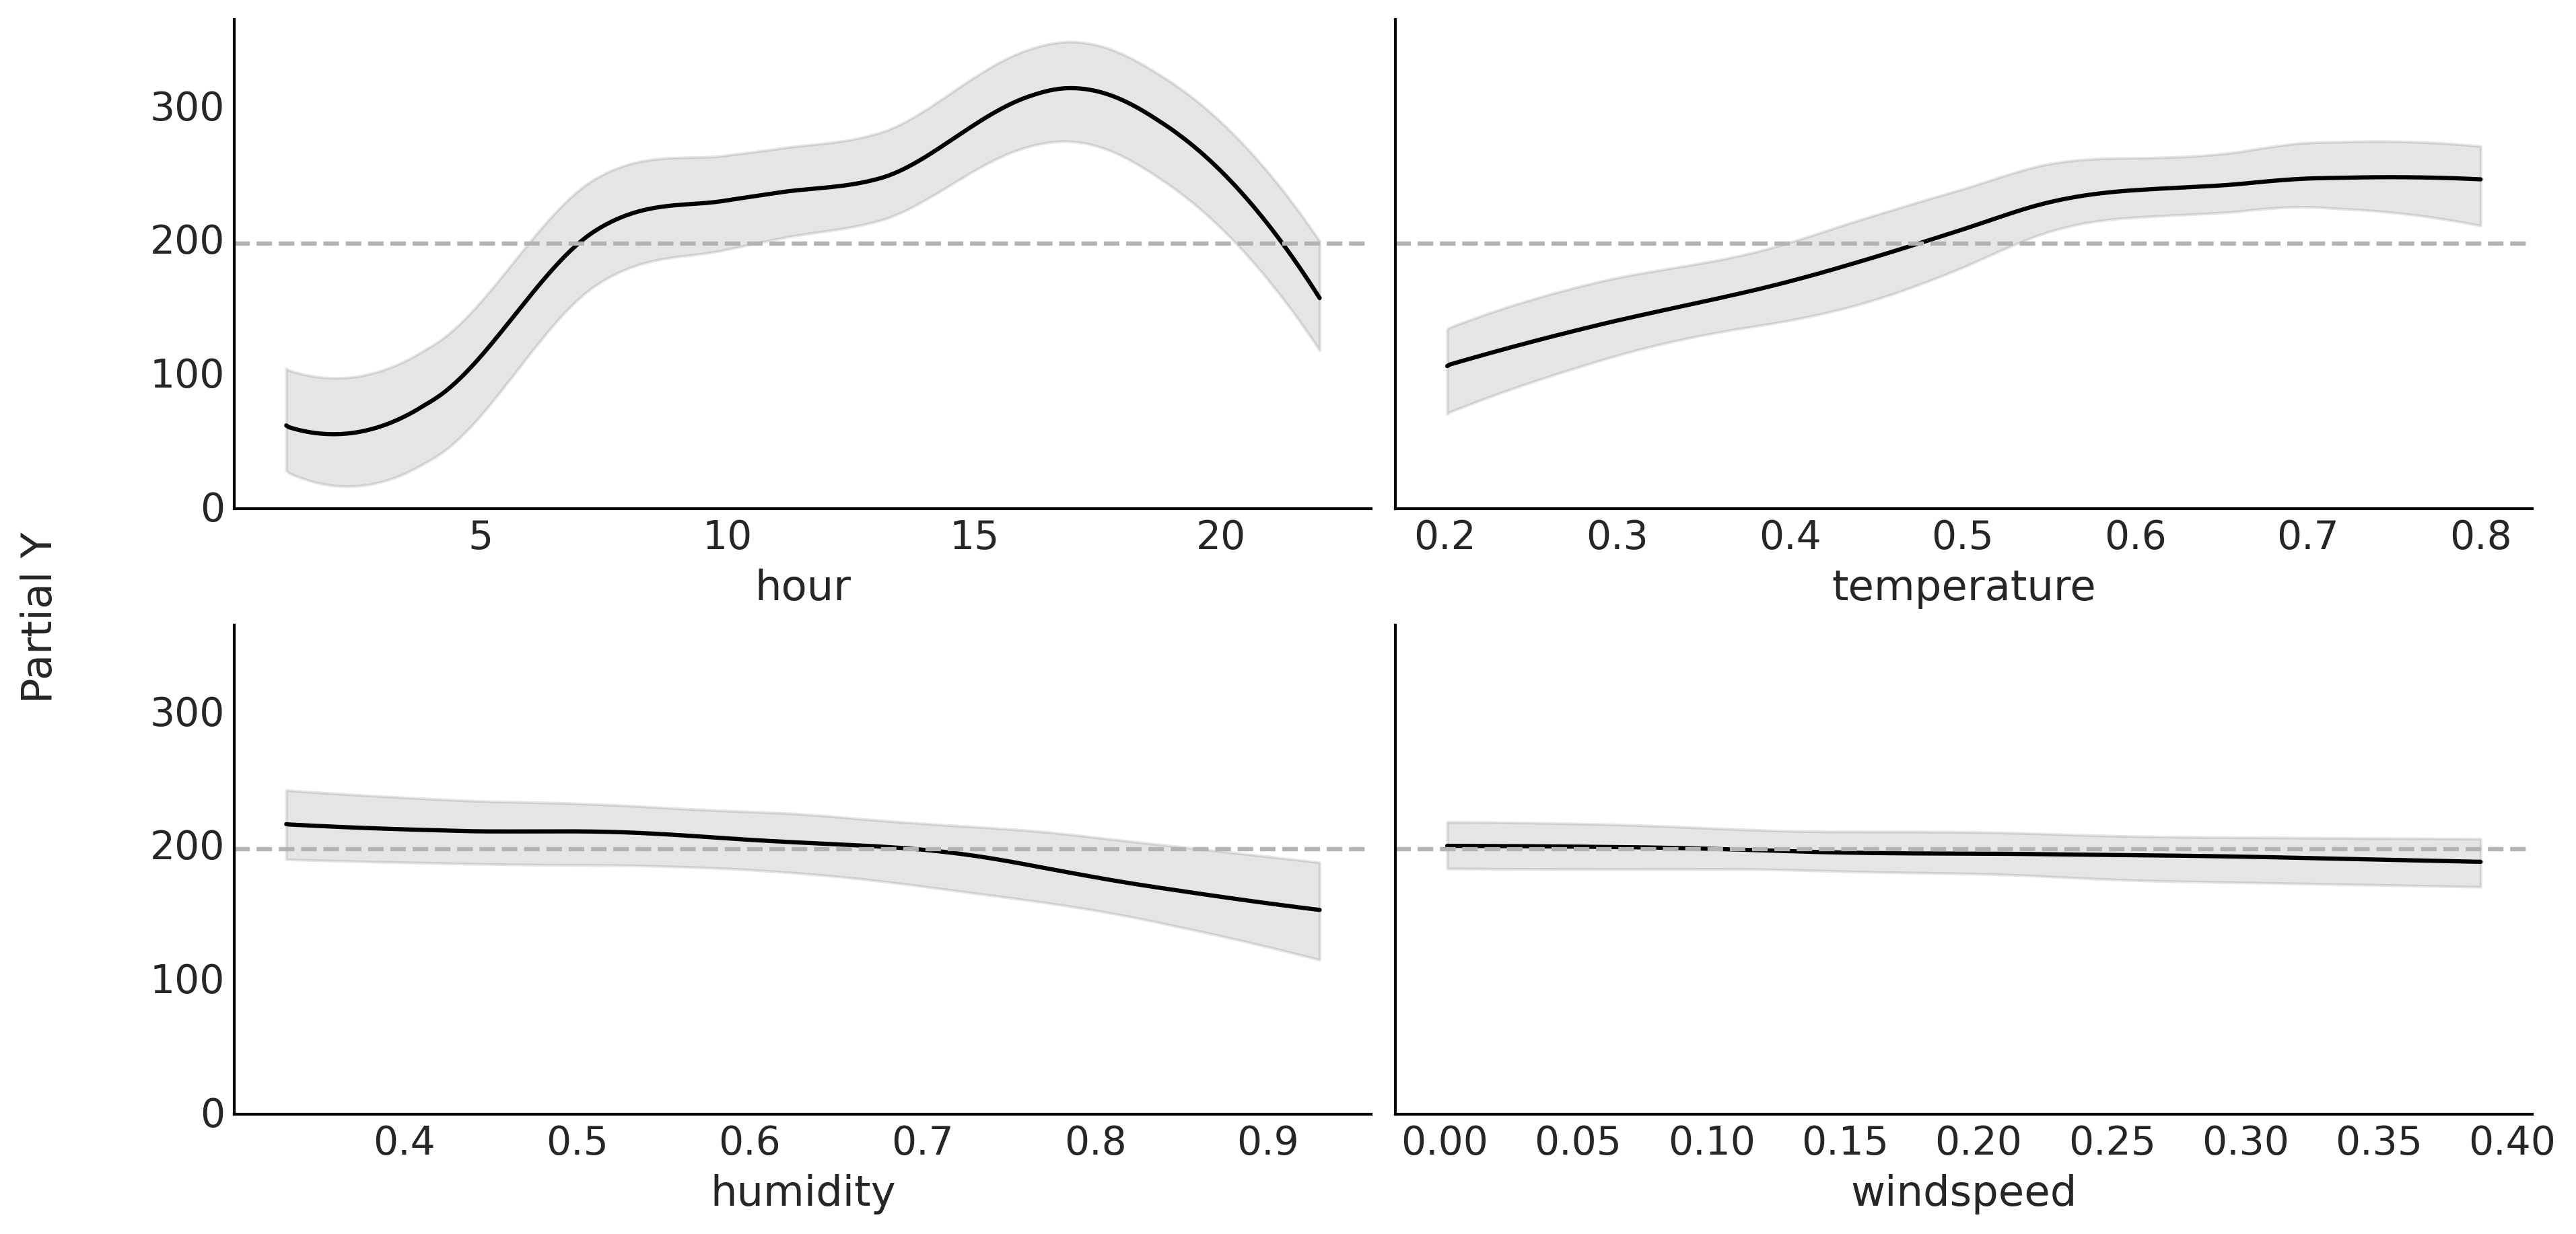

In [17]:
pmb.plot_pdp(μ, X, grid=(2, 2), figsize=(12, 6), sharey=True)
plt.savefig("img/chp07/partial_dependence_plot_bikes.png", bbox_inches="tight")

(individual-conditional-expectation)=

### 7.7.2. Individual Conditional Expectation

Individual Conditional Expectation (ICE) plots are closely related to
PDPs. The difference is that instead of plotting the target covariates'
average partial effect on the predicted response, we plot the $n$
estimated conditional expectation curves. That is, each curve in an ICE
plot reflects the partial predicted response as a function of covariate
$\boldsymbol{X}_{i}$ for a fixed value of $\boldsymbol{X}_{-ij}$. See
{numref}`fig:individual_conditional_expectation_plot_bikes` for an
example. If we average all the gray curves at each $\boldsymbol{X}_{ij}$
value we get the blue curve, which is the same curve that we should have
obtained if we have computed the mean partial dependence in
{numref}`fig:partial_dependence_plot_bikes`.

```{figure} figures/individual_conditional_expectation_plot_bikes.png
:name: fig:individual_conditional_expectation_plot_bikes
:width: 8.00in
Individual conditional expectation plot. Partial contribution to the
number of rented bikes from the variables; hour, temperature, humidity
and wind speed while fixing the rest ($X_{-i}$) at one observed value.
The blue curve corresponds to the average of the gray curves. All curves
have been smoothed (see `plot_ice` function). The rugplot, the black
bars at the bottom of each subplot, shows the observed values for each
covariate.
```

Individual conditional expectation plots are best suited to problems
where variable have strong interactions, when this is not the case
partial dependence plots and individual conditional expectations plots
convey the same information. {numref}`fig:pdp_vs_ice_toy` shows an
example where the partial dependence plots hides a relationship in the
data, but an individual conditional expectation plot is able to show it
better. The plot was generated by fitting a BART model to the synthetic
data: $Y = 0.2X_0 - 5X_1 + 10X_1 \unicode{x1D7D9}_{X_2 \geq 0} + \epsilon$
where $X \sim \mathcal{U}(-1, 1)$ $\epsilon \sim \mathcal{N}(0, 0.5)$.
Notice how the value of $X_1$ depends on the value of $X_2$.

```{figure} figures/pdp_vs_ice_toy.png
:name: fig:pdp_vs_ice_toy
:width: 8.00in
Partial dependence plot vs individual conditional expectation plot.
First panel, scatter plot between $X_1$ and $Y$, middle panel partial
dependence plot, last panel individual conditional expectation plot.
```

In the first panel of {numref}`fig:pdp_vs_ice_toy` we plot $X_1$ versus
$Y$. Given that there is an interaction effect that the value of $Y$ can
linearly increase or decrease with $X_1$ conditional on the values of
the $X_2$ variable, the plot displays the *X-shaped* pattern. The middle
panel shows a partial dependence plot, we can see that according to this
plot the relationship is flat, which is true *on average* but hides the
interaction effect. On the contrary the last panel, an individual
conditional expectation plot helps to uncover this relationship. The
reason is that each gray curve represents one value of $X_{0,2}$ [^7].
The blue curve is the average of the gray curves and while is not
exactly the same as the partial dependence mean curve it shows the same
information [^8].

[^7]: This notation means the variables ($X_0$, $X_2$), that is,
    excluding $X_1$

[^8]: The mean of the ICE curves and the mean partial dependence curve
    are slightly different. This is due to internal details on how these
    plots were made including the order in which we average over the
    posterior samples or over the observations. What really matter is
    the general features, for instance in this case that both curves are
    essentially flat. Also, to speed up computation we evaluate $X_1$
    over 10 equally separated points for partial dependence plots and we
    subsample $X_{0,2}$ for computing the individual conditional
    expectation plot

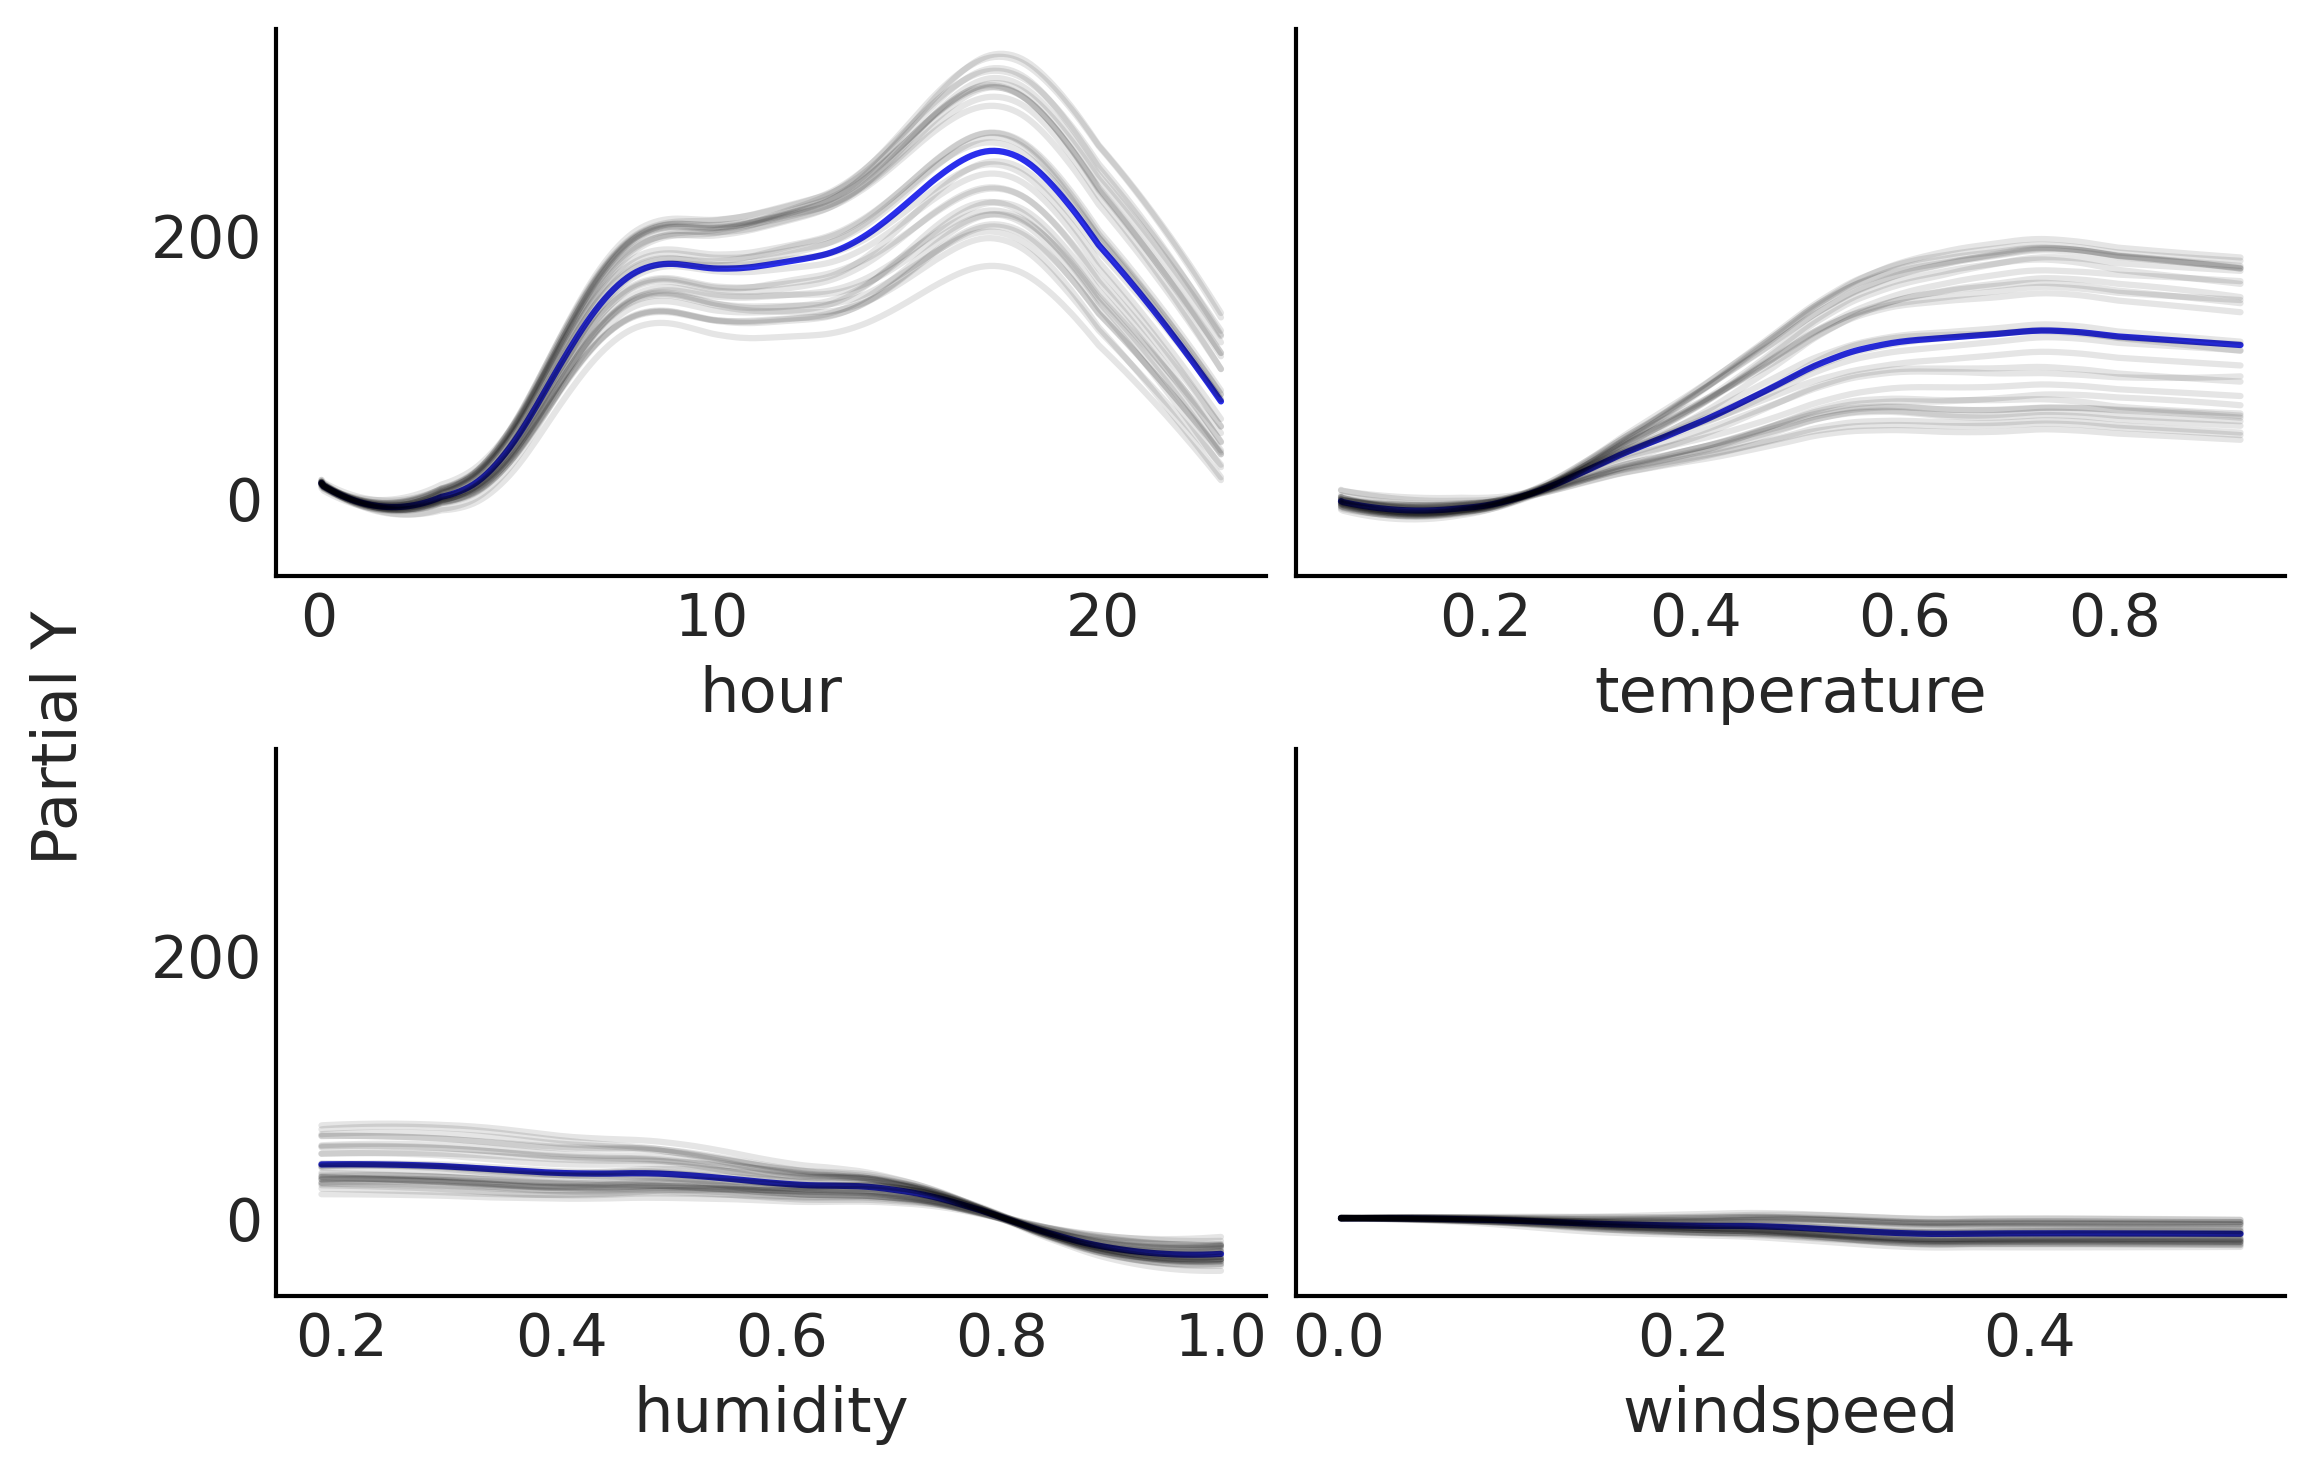

In [18]:
pmb.plot_ice(μ, X, grid=(2,2), smooth=True, color_mean="C4")
plt.savefig("img/chp07/individual_conditional_expectation_plot_bikes.png", bbox_inches="tight")

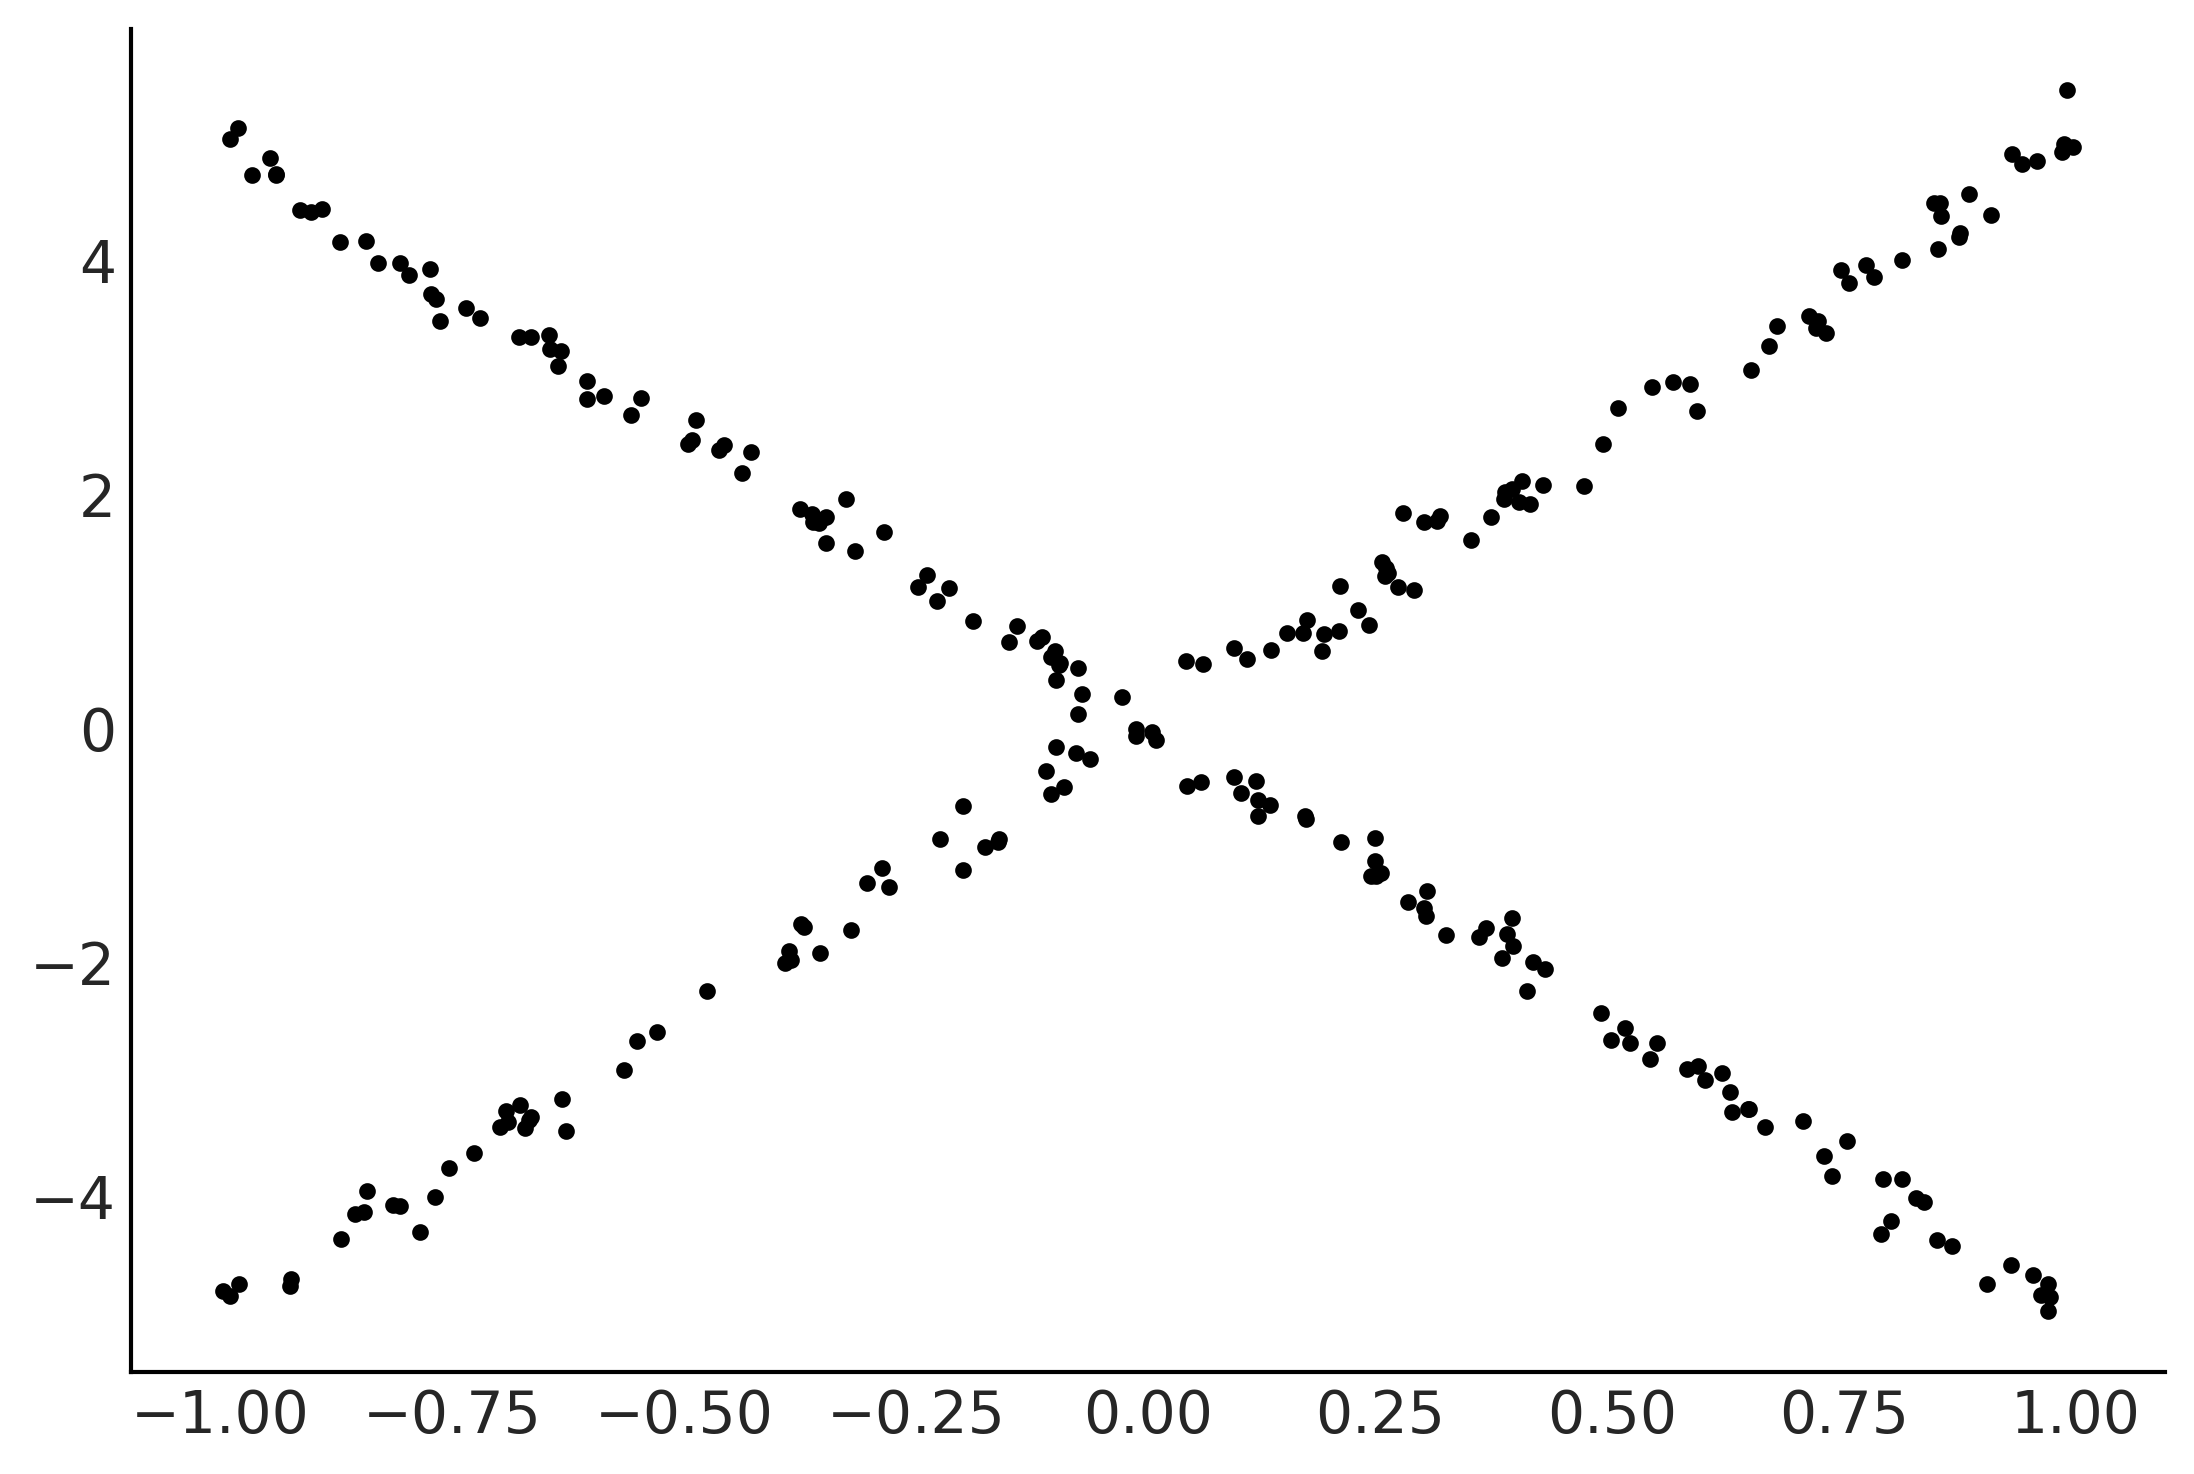

In [19]:
X = np.random.uniform(-1, 1, (250, 3))
Z = np.where(X[:,2] >= 0,  np.zeros_like(X[:,2]), np.ones_like(X[:,2]))
e = np.random.normal(0, 0.1, 250)
Y = 0.2*X[:,0] - 5*X[:,1] + 10*X[:,1] * Z + e


plt.plot(X[:,1], Y, '.');

In [20]:
with pm.Model() as model:
    μ = pmb.BART('μ', X, Y, m=200)
    σ = pm.HalfNormal('σ', 1)

    y = pm.Normal('y', μ, σ, observed=Y)
    trace_u = pm.sample()

/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  self.pid = os.fork()
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>PGBART: [μ]
>NUTS: [σ]
/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is

Output()

/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 101 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


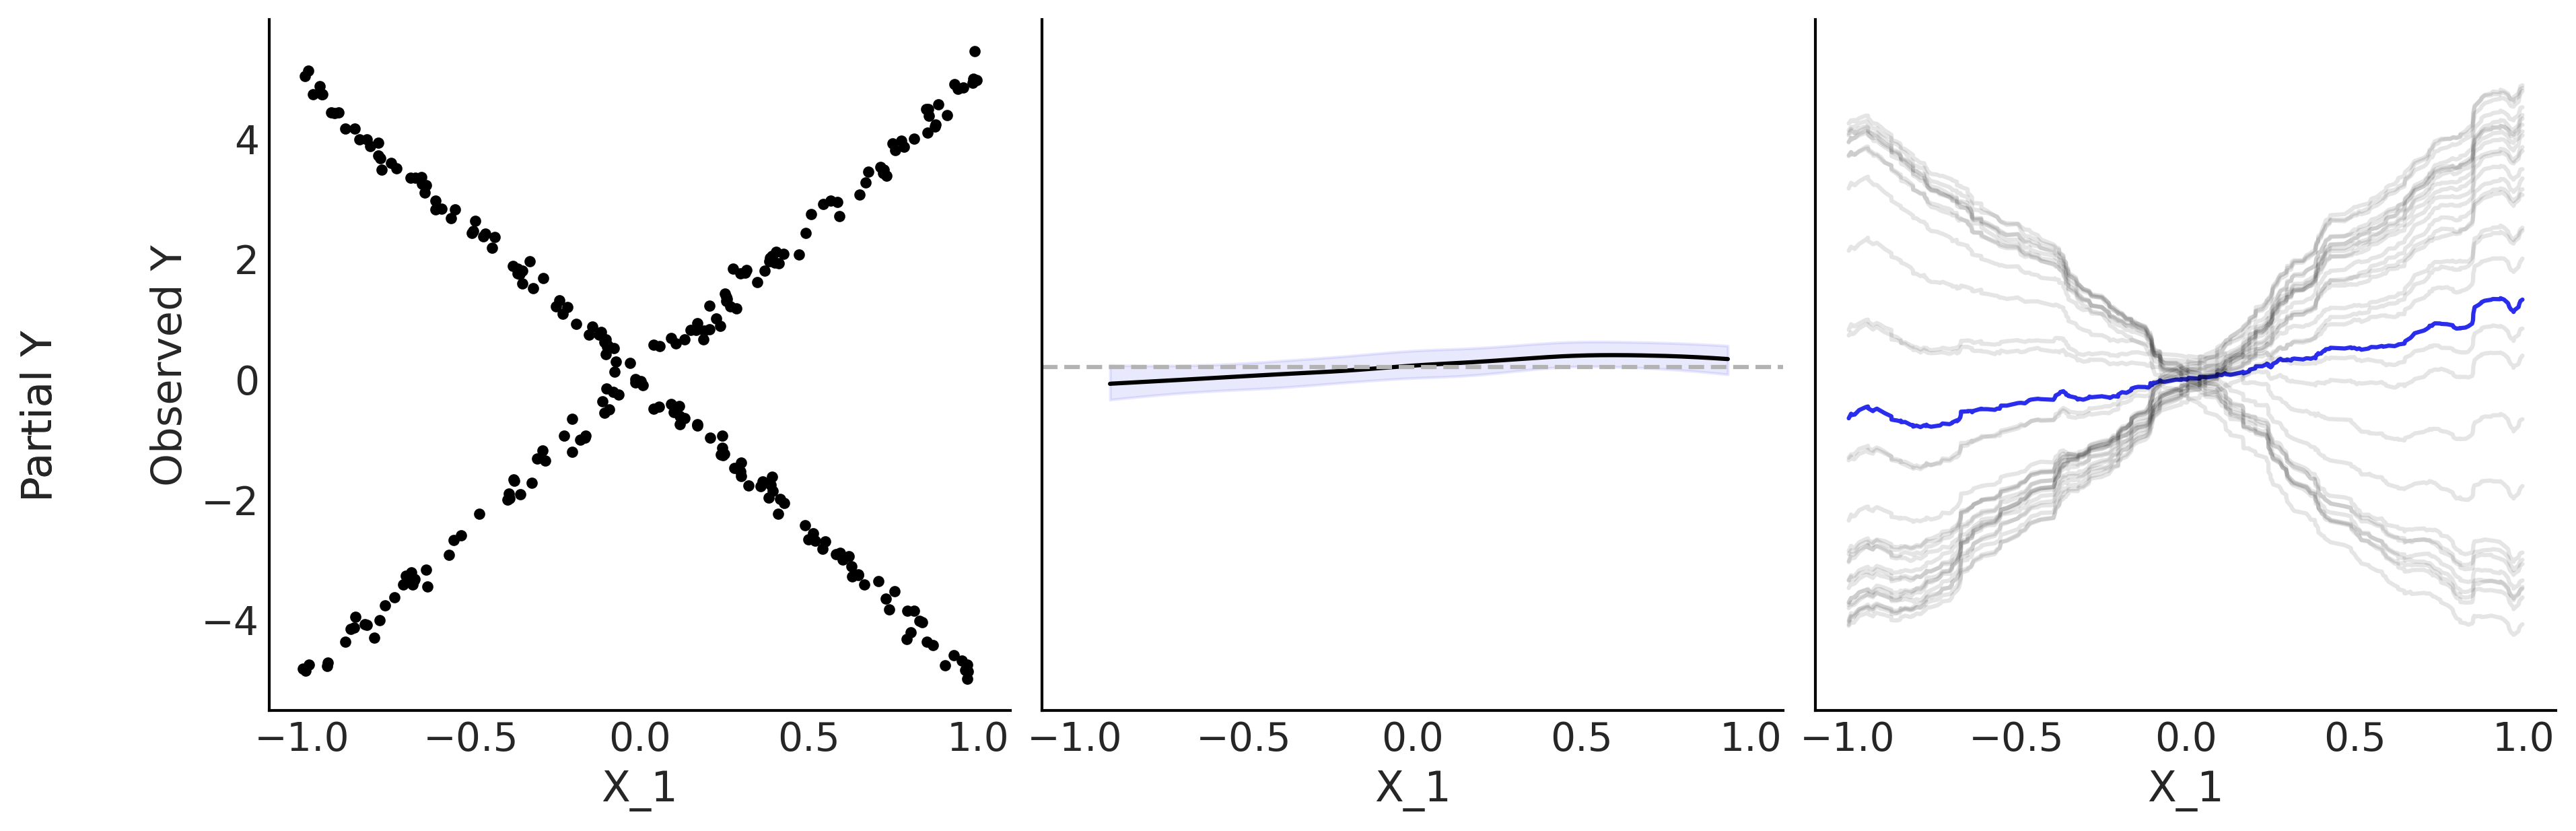

In [21]:
_, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True, sharex=True)
ax[0].plot(X[:,1], Y, '.');
ax[0].set_xlabel("X_1")
ax[0].set_ylabel("Observed Y")
pmb.plot_pdp(μ, X, smooth=True, color="C4", var_idx=[1], ax=ax[1])
pmb.plot_ice(μ, X, centered=False, smooth=False, color_mean="C4", var_idx=[1], ax=ax[2])
plt.savefig("img/chp07/pdp_vs_ice_toy.png", bbox_inches="tight")

(sec:variable_selection)=

## 7.8. Variable Selection

When fitting regressions with more than one predictor it is often of
interest to learn which predictors are most important. Under some
scenarios we may be genuinely interested in better understanding how
different variables contribute to generate a particular output. For
example, which dietary and environmental factors contribute to colon
cancer. In other instances collecting a dataset with many covariates may
be unaffordable financially, take too long, or be too complicated
logistically. For example, in medical research measuring a lot of
variable from a human can be expensive, time consuming or annoying (or
even risky for the patient). Hence we can afford to measure a lot of
variables in a pilot study, but to scale such analysis to a larger
population we may need to reduce the number of variables. In such cases
we want to keep the smallest (cheapest, more convenient to obtain) set
of variables that still provide a reasonable high predictive power. BART
models offer a very simple, and almost computational-free, heuristic to
estimate variable importance. It keeps track of how many times a
covariate is used as a splitting variable. For example, in
{numref}`fig:decision_tree` we have two splitting nodes one includes
variable $X_1$ and the other $X_2$, so based on this tree both variables
are equally important. If instead we would have count $X_1$ twice and
$X_2$ once. We would say that $X_1$ is twice as important as $X_2$. For
BART models the variable importance is computed by averaging over the
$m$ trees and over all posterior samples. Note that using this simple
heuristic we can only report the importance in relative fashion, as
there is not simple way to say this variable is important and this
another one not important.

To further ease interpretation we can report the values normalized so
each value is in the interval $[0, 1]$ and the total importance is 1. It
is tempting to interpret these numbers as posterior probabilities, but
we should keep in mind that this is just a simple heuristic without a
very strong theoretical support, or to put it in more nuanced terms, it
is not yet well understood {cite:p}`Liu2020`.

{numref}`fig:bart_vi_toy` shows the relative variable importance for 3
different datasets from known generative processes.

-   $Y \sim \mathcal{N}(0, 1)$ $X_{0} \sim \mathcal{N}(Y, 0.1)$ and
    $X_{1} \sim \mathcal{N}(Y, 0.2)$
    $\boldsymbol{X}_{2:9} \sim \mathcal{N}(0, 1)$. Only the first 2
    independent variables are related to the predictor, and the first
    is more related than the second.

-   $Y = 10 \sin(\pi X_0 X_1 ) + 20(X_2 - 0.5)^2 + 10X_3 + 5X_4 + \epsilon$
    Where $\epsilon \sim \mathcal{N}(0, 1)$ and
    $\boldsymbol{X}_{0:9} \sim \mathcal{U}(0, 1)$ This is usually called
    the Friedman's five dimensional test function {cite:p}`Friedman2001`.
    Notice that while the first five random variables are related to $Y$
    (to different extend) the last 5 are not.

-   $\boldsymbol{X}_{0:9} \sim \mathcal{N}(0, 1)$ and
    $Y \sim \mathcal{N}(0, 1)$. All variables are unrelated to the
    response variable.

```{figure} figures/bart_vi_toy.png
:name: fig:bart_vi_toy
:width: 8.00in
Relative variable importance. Left panel, the first 2 input variables
contribute to the predictor variable and the rest are noise. Middle
panel, the first 5 variable are related to the output variable. Finally
on the right panel the 10 input variables are completely unrelated to
the predictor variable. The black dashed line represents the value of
the variable importance if all variables were equally important.
```

The new version of BART uses a different algorithm to compute the variable importance. With this method the variable importance is robust to the number of trees and results are easier to interpret. Instead of reporting the value of the variable importance we report the value of R² (the square of the pearson correlation coefficient) between the model with all variables, versus model with a subset of the variables. To see how this works in practice we are going to fit the 3 same models as in the book, but with the new version of BART.

In [22]:
Xs = []
Ys = []


Y = np.random.normal(0, 1, 100)
X = np.random.normal(0, 1, (100, 10))
X[:,0] = np.random.normal(Y, 0.1)
X[:,1] = np.random.normal(Y, 0.2)
Xs.append(X)
Ys.append(Y)


X = np.random.uniform(0, 1, size=(100, 10))
fx = 10 * np.sin(np.pi*X[:,0]* X[:,1]) + 20*(X[:,2] - 0.5)**2 + 10*X[:,3] + 5*X[:,4]
Y =  np.random.normal(fx, 1)
Xs.append(X)
Ys.append(Y)


Y = np.random.normal(0, 1, 100)
X = np.random.normal(0, 1, (100, 10))
Xs.append(X)
Ys.append(Y)

In [23]:
idatas = []
bart_rvs = []

for X, Y in zip(Xs, Ys):
    with pm.Model() as bart:
        σ = pm.HalfNormal('σ', Y.std())
        μ = pmb.BART('μ', X, Y)
        y = pm.Normal('y', μ, σ, observed=Y)
        bart_rvs.append(μ)
        idatas.append(pm.sample())

/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  self.pid = os.fork()
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [σ]
>PGBART: [μ]
/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is

Output()

/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 32 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiproc

Output()

/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 25 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  self.pid = os.fork()
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [σ]
>PGBART: [μ]
/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiproces

Output()

/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 26 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


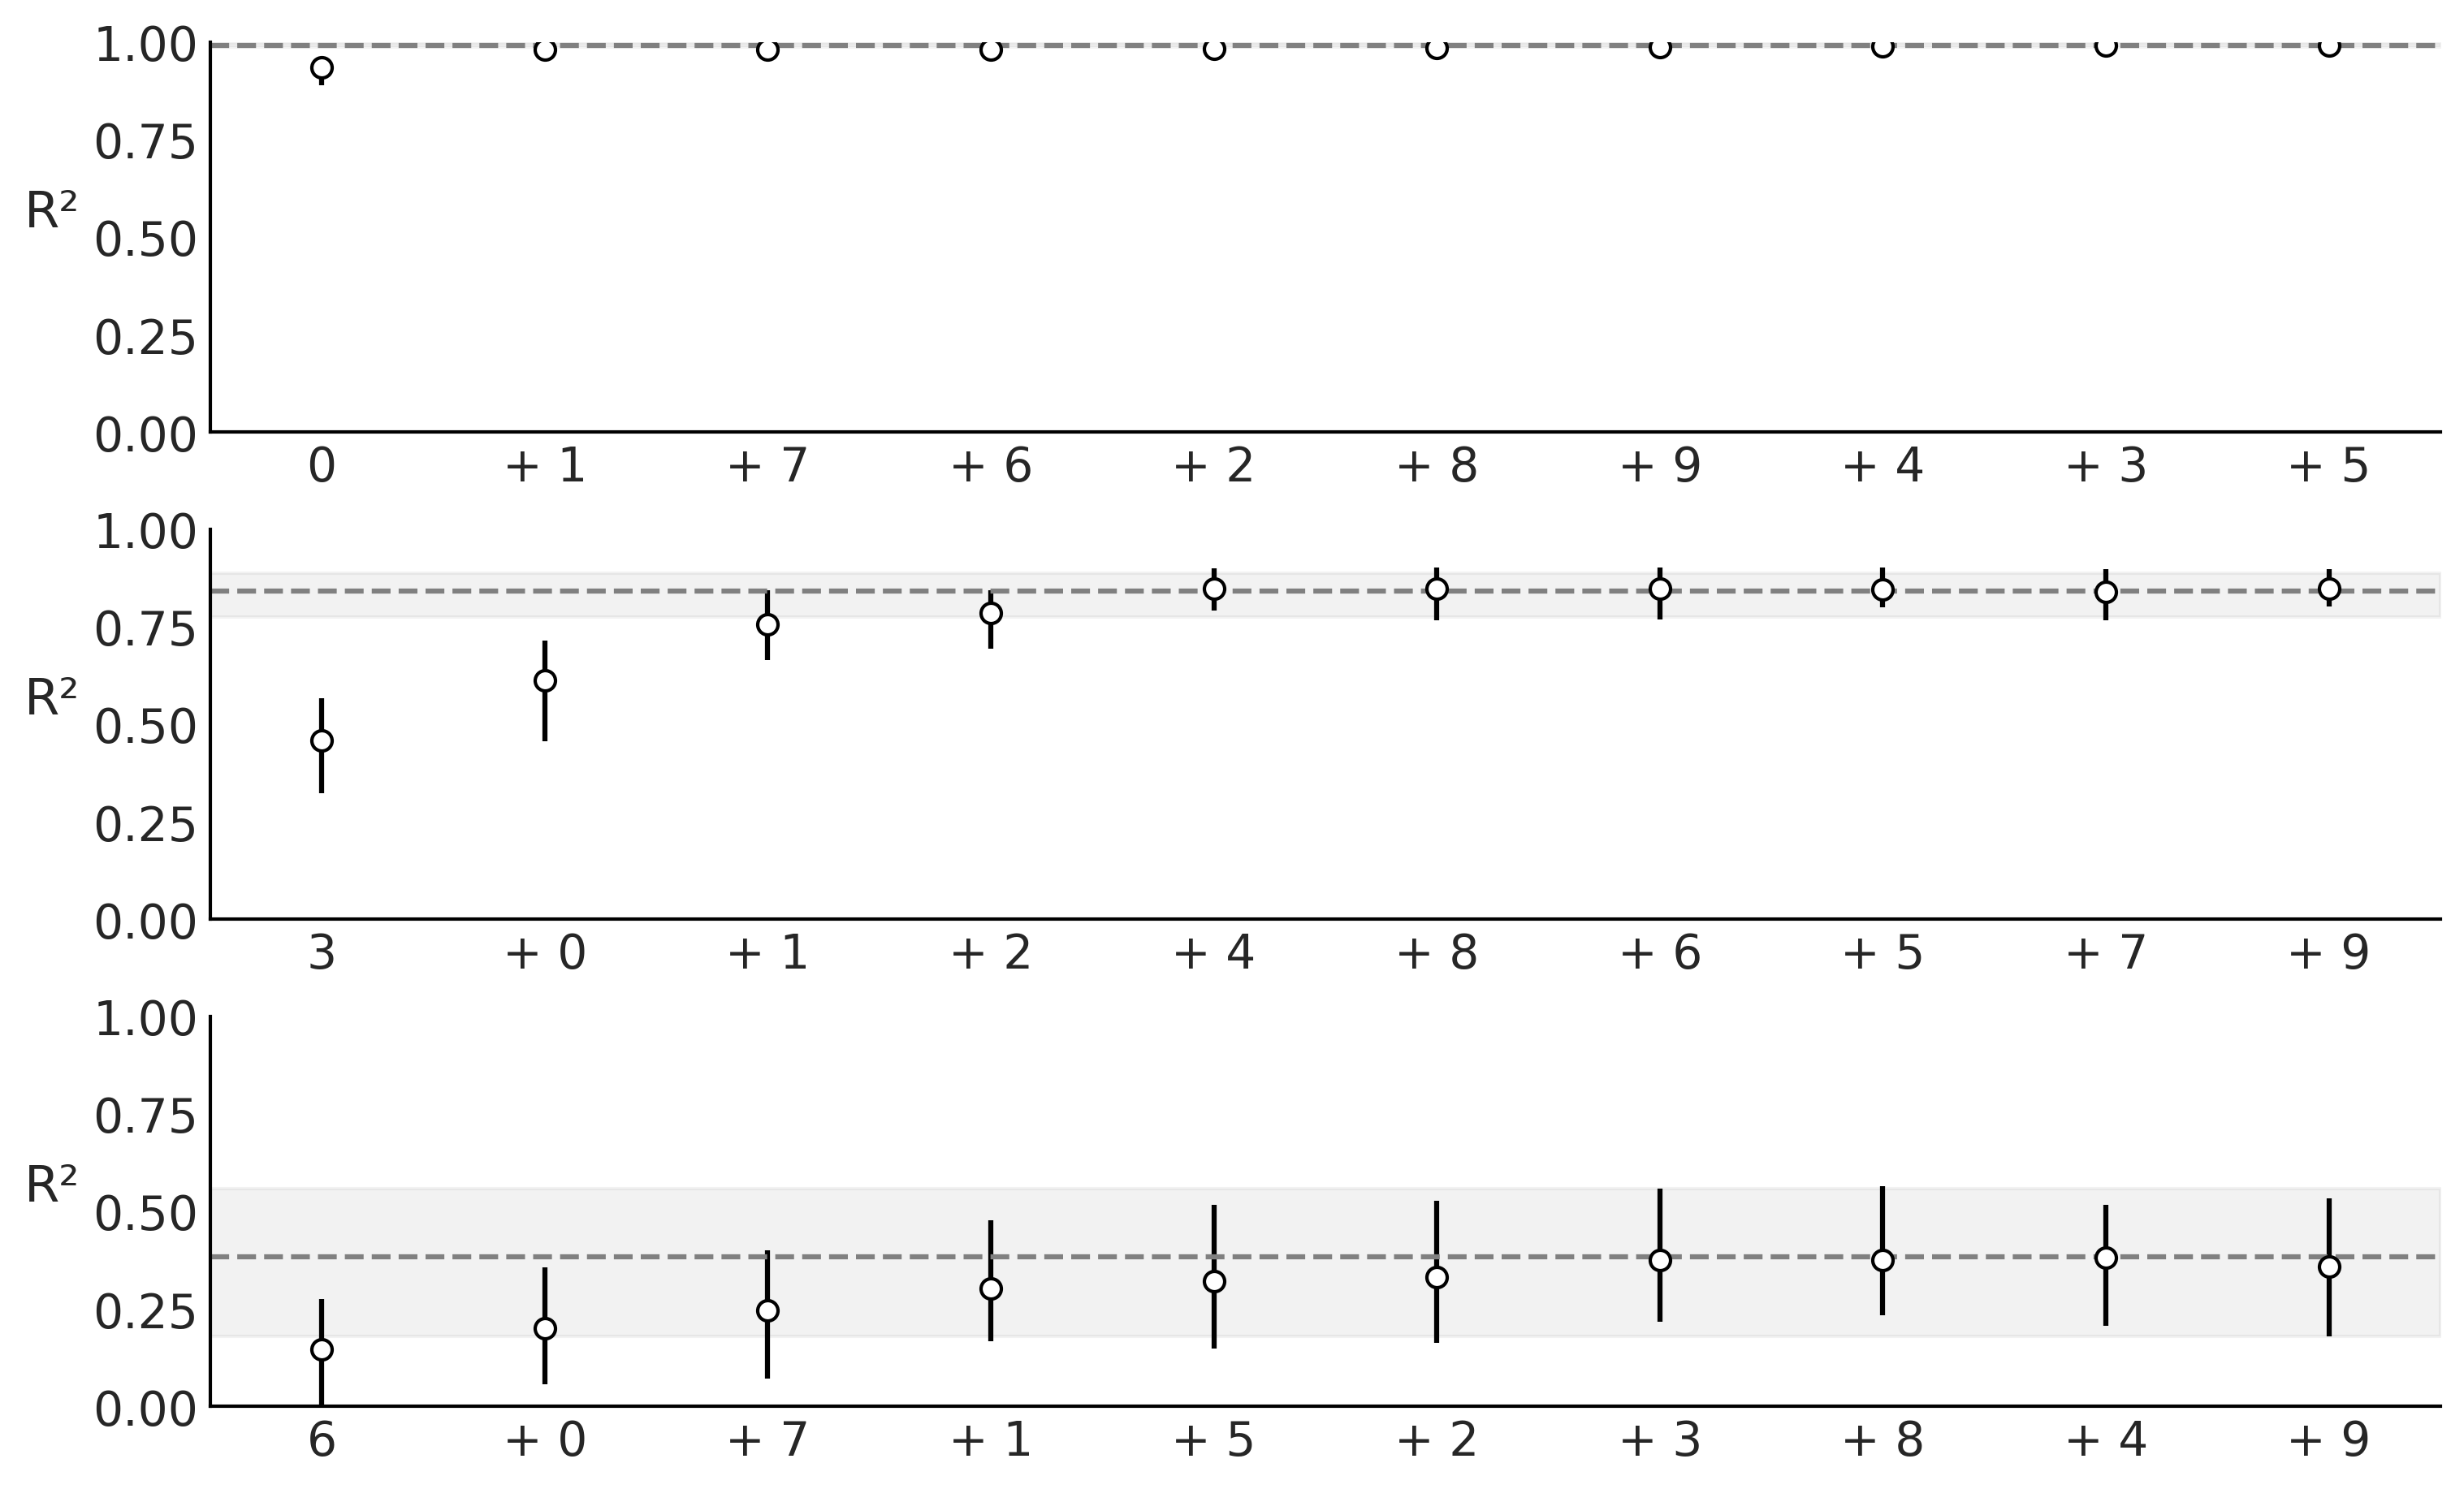

In [24]:
_, axes = plt.subplots(3, 1, figsize=(10, 6))

for j, X in enumerate(Xs):
    vi_results = pmb.compute_variable_importance(idatas[j], bart_rvs[j], X)
    pmb.plot_variable_importance(vi_results, figsize=(10, 5), ax=axes[j])
        
plt.savefig("img/chp07/bart_vi_toy.png", bbox_inches="tight")

One thing we can see from {numref}`fig:bart_vi_toy` is the effect of
increasing the number of trees $m$. In general, as we increase $m$, the
distribution of the relative importance tends to become *flatter*. This
is a well known observation with an intuitive explanation. As we
increase the value of $m$ we demand less predictive power from each
tree, this implies that less relevant features have a higher chance to
be part of a given tree. On the contrary, if we decrease the value of
$m$ we demand more from each single tree and this induces a more
stringent *competition* between variables to be part of the trees, as a
consequence only the *really important* variables will be included in
the final trees.

Plots like {numref}`fig:bart_vi_toy` can be used to help separate the
more important variables from the less important ones
{cite:p}`ChipmanBARTBayesianadditive2010, Carlson2020`. This can be done by
looking at what happens when we move from low values of $m$ to higher
ones. If the relative importance decreases the variable is *more
important* and if the variable importance increases then the variable is
*less important*. For example, in the first panel it is clear that for
different values of $m$ the first two variables are much more important
than the rest. And something similar can be concluded from the second
panel for the first 5 variables. On the last panel all variables are
equally (un)important.

This way to assess variable importance can be useful, but also tricky.
Under some circumstances it can help to have confidence intervals for
the variable importance and not just point estimates. We can do this by
running BART many times, with the same parameters and data.
Nevertheless, the lack of a clear threshold separating the important
from the unimportant variables can be seen as problematic. Some
alternative methods have been proposed {cite:p}`Carlson2020, Bleich2014`. One
of such methods can be summarized as follow:

1.  Fit a model many times (around 50) using a small value of $m$, like
    25 [^9]. Record the root mean squared error.

2.  Eliminate the least informative variable across all 50 runs.

3.  Repeat 1 and 2, each time with one less variable in the model. Stop
    once you reach a given number of covariates in the model (not
    necessarily 1).

4.  Finally, select the model with the lowest average root mean square
    error.

According to Carlson {cite:p}`Carlson2020` this procedure seems to almost
always return the same result as just creating a figure like
{numref}`fig:bart_vi_toy`. Nevertheless one can argue that is more
automatic (with all the pros and cons of automatic decisions). Also
nothing prevents us for doing the automatic procedure and then using the
plot as a visual check.

Let us move to the rent bike example with the four covariates: hour,
temperature, humidity and windspeed. From {numref}`fig:bart_vi_bikes` we
can see that hour and temperature are more relevant to predict the
number of rented bikes than humidity or windspeed. We can also see that
the order of the variable importance qualitatively agrees with the
results from partial dependence plots (Figure
{numref}`fig:partial_dependence_plot_bikes`) and individual conditional
expectation plots (Figure
{numref}`fig:individual_conditional_expectation_plot_bikes`).

```{figure} figures/bart_vi_bikes.png
:name: fig:bart_vi_bikes
:width: 8.00in
Relative variable importance from fitted BARTs with different number of
trees. Hour is the most important covariate followed by the temperature.
The humidity and windspeed appear as less relevant covariates.
```

[^9]: The original proposal suggests 10, but our experience with the
    BART implementation in PyMC3 is that values of $m$ below 20 or 25
    could be problematic.

In [25]:
data = pd.read_csv("../data/bikes_hour.csv")
data.sort_values(by='hour', inplace=True)
data = data[::50]
X = data[["hour", "temperature", "humidity", "windspeed"]]
Y = data["count"]

In [26]:
with pm.Model() as bart:
    σ = pm.HalfNormal('σ', Y.std())
    μ = pmb.BART('μ', X, Y)
    y = pm.Normal('y', μ, σ, observed=Y)
    idata = pm.sample()

/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  self.pid = os.fork()
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [σ]
>PGBART: [μ]
/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is

Output()

/home/hwting/anaconda3/envs/rapids-24.12/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 27 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


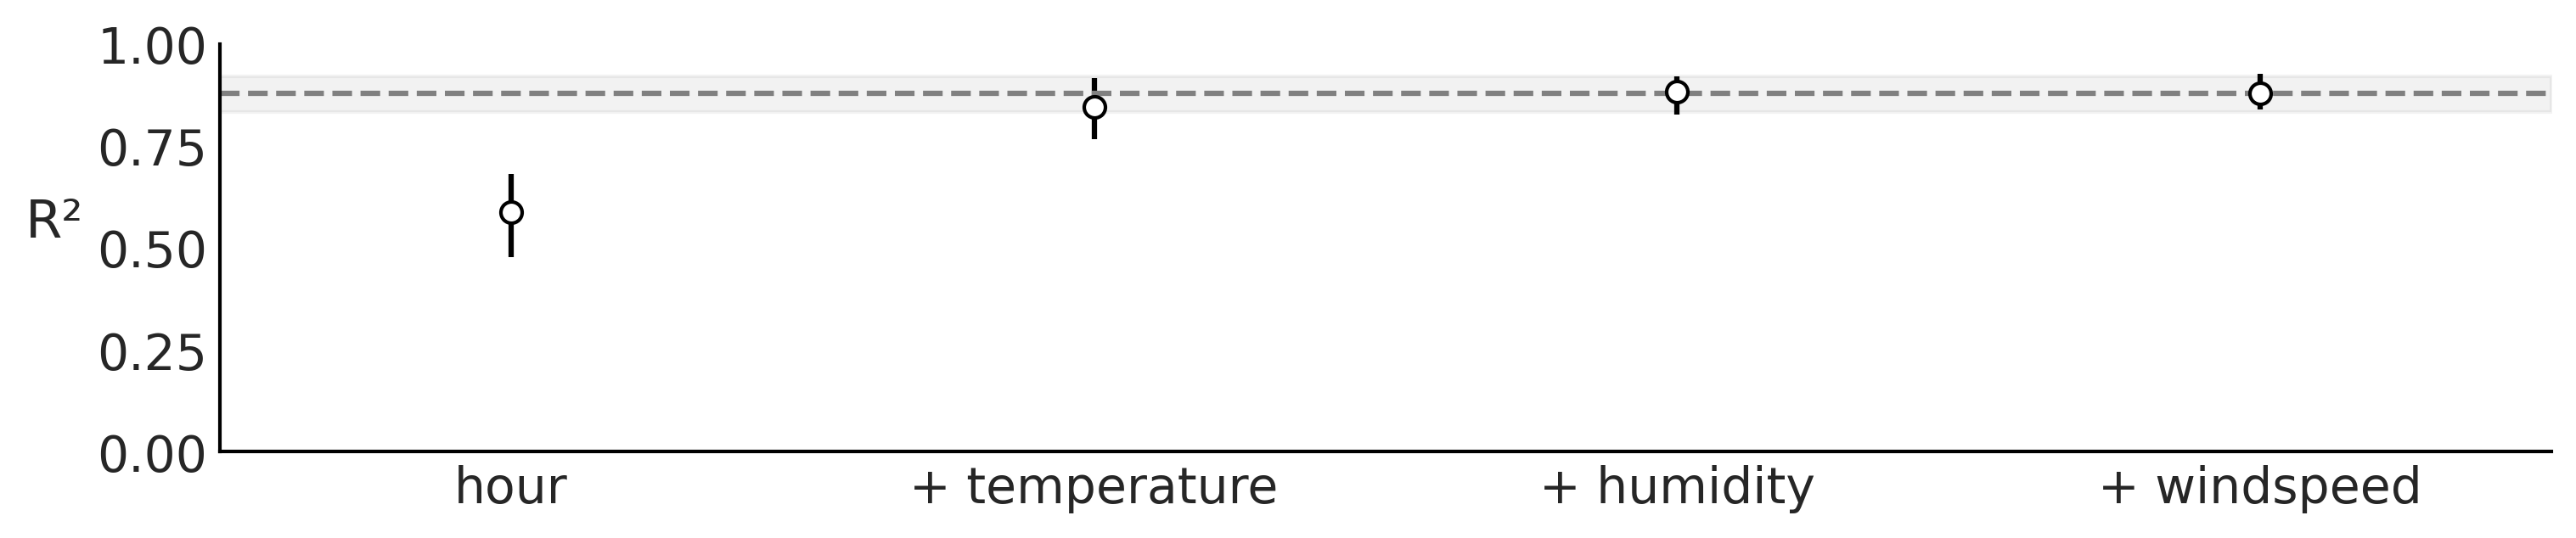

In [27]:
vi_results = pmb.compute_variable_importance(idata, μ, X)
pmb.plot_variable_importance(vi_results, figsize=(10, 2));

(priors-for-bart-in-pymc3)=

## 7.9. Priors for BART in PyMC3

Compared to other models in this book, BARTs are the most *blackboxsy*.
We are not able to set whatever priors we want to generate a BART model.
We instead control predefined priors through a few parameters. PyMC3
allows to control priors for BARTS with 3 arguments:

-   The number of trees $m$

-   The depth of the trees $\alpha$

-   The distribution over the split variables.

We saw the effect of changing the number of trees, which has been shown
to provide robust predictions for values in the interval 50-200. Also
there are many examples showing that using cross-validation to determine
this number can be beneficial. We also saw that by scanning $m$ for
relative low values like in the range 25-100 we can evaluate the
variable importance. We did not bother to change the default value of
$\alpha=0.25$ as this change seems to have even less impact, although
research is still needed to better understand this prior {cite:p}`Rockova2018`.
As with $m$ cross-validation can also be used to tune it for better
efficiency. Finally PyMC3 provides the option to pass a vector of
weights so different variables have different prior probabilities of
being selected, this can be useful when the user has evidence that some
variables may be more important than others, otherwise it is better to
just keep it Uniform. More sophisticated Dirichlet-based priors have
been proposed [^10] to achieve this goal and to allow for better
inference when inducing sparsity is desired. This is useful in cases
where we have a lot of covariates, but only a few are likely to
contribute and we do not know beforehand which ones are the most
relevant. This is a common case, for example, in genetic research where
measuring the activity of hundreds or more genes is relatively easy but
how they are related is not only not known but the goal of the research.

Most BART implementations have been done in the context of individual
packages, in some cases even oriented to particular sub-disciplines.
They are typically not part of probabilistic programming languages, and
thus users are not expected to tweak BART models too much. So even when
it could be possible to put a prior directly over the number of trees,
this is not generally how it is done in practice. Instead the BART
literature praises the good performance of BART with default parameters
while recognizing that cross-validation can be used to get some extra
juice. The BART implementation in PyMC3 slightly departure from this
tradition, and allows for some extra flexibility, but is still very
limited, compared to how we use other like Gaussian or Poisson
distribution, or even non-parametric distributions like Gaussian
Processes. We envision that this may change in the not so far future,
partly because of our interest in exploring more flexible
implementations of BART that could allow users to build flexible and
problem-tailored models as is usually the case with probabilistic
programming languages.

[^10]: This is likely to be added in the future versions of PyMC3.

(exercises7)=

## 7.10. Exercises

**7E1.** Explain each of the following

1.  How is BART different from linear regression and splines.

2.  When you may want to use linear regression over BART?

3.  When you may want to use splines over BART?

**7E2.** Draw at least two more trees that could be used to
explain the data in {numref}`fig:decision_tree`.

**7E3.** Draw a tree with one more internal node than the one
in {numref}`fig:decision_tree` that explains the data equally well.

**7E4.** Draw a decision tree of what you decide to wear each
morning. Label the leaf nodes and the root nodes.

**7E5.** What are the priors required for BART? Explain what
is the role of priors for BART models and how is this similar and how is
this different from the role of priors in the models we have discussed
in previous chapters.

**7E6.** In your own words explain why it can be the case
that multiple small trees can fit patterns better than one single large
tree. What is the difference in the two approaches? What are the
tradeoffs?

**7E7.** Below we provide some data. To each data fit a BART
model with m=50. Plot the fit, including the data. Describe the fit.

1.  `x = np.linspace(-1, 1., 200)` and `y = np.random.normal(2*x, 0.25)`

2.  `x = np.linspace(-1, 1., 200)` and
    `y = np.random.normal(x**2, 0.25)`

3.  pick a function you like

4.  compare the results with the exercise **5E4.** from Chapter [5](chap3_5)

**7E8.** Compute the PDPs For the dataset used to generate
{numref}`fig:bart_vi_toy`. Compare the information you get from the
variable importance measure and the PDPs.

**7M9**. For the rental bike example we use a Gaussian as
likelihood, this can be seen as a reasonable approximation when the
number of counts is large, but still brings some problems, like
predicting negative number of rented bikes (for example, at night when
the observed number of rented bikes is close to zero). To fix this issue
and improve our models we can try with other likelihoods:

1.  use a Poisson likelihood (hint you will need to use an inverse link
    function, check `pm.Bart` docstring). How the fit differs from the
    example in the book. Is this a better fit? In what sense?

2.  use a NegativeBinomial likelihood, how the fit differs from the
    previous two? Could you explain the result.

3.  how this result is different from the one in Chapter
    [5](chap3_5)? Could you explain the difference?

**7M10.** Use BART to redo the first penguin classification
examples we performed in Section {ref}`classifying_penguins` (i.e. use
"bill_length_mm" as covariate and the species "Adelie" and "Chistrap" as
the response). Try different values of `m` like, 4, 10, 20 and 50 and
pick a suitable value as we did in the book. Visually compare the
results with the fit in
{numref}`fig:Logistic_bill_length`. Which model do
you think performs the best?

**7M11.** Use BART to redo the penguin classification we
performed in Section {ref}`classifying_penguins`. Set
`m=50` and use the covariates "bill_length_mm", "bill_depth_mm",
"flipper_length_mm" and "body_mass_g".

Use Partial Dependence Plots and Individual Conditional Expectation. To
find out how the different covariates contribute the probability of
identifying "Adelie", and "Chinstrap" species.

Refit the model but this time using only 3 covariates "bill_depth_m",
"flipper_length_mm", and "body_mass_g". How results differ from using
the four covariates? Justify.

**7M12.** Use BART to redo the penguin classification we
performed in Section {ref}`classifying_penguins`. Build a
model with the covariates "bill_length_mm", "bill_depth_mm",
"flipper_length_mm", and "body_mass_g" and assess their relative
variable importance. Compare the results with the PDPs from the previous
exercise.